
# Big Five Human vs AI Psychometric Fidelity Notebook

This Colab notebook runs a full **five-level evaluation framework** for Big Five questionnaire responses:

1. **Central tendency fidelity**
2. **Distribution fidelity**
3. **Reliability fidelity**
4. **Structural fidelity**
5. **Behavioral fidelity**

It is built for your two-file workflow:
- one **AI/model** file with a `model` column and the 50 Big Five item columns
- one **human** file with the same 50 item columns, plus optional quality flags such as `exclude_any`

The notebook:
- asks you to **upload both files**
- parses and validates the schema
- reverse-codes items using a data-driven key (with override support)
- scores the five traits
- runs the main tests at each level
- produces **publication-ready tables and figures**
- writes all outputs to an `outputs/` folder for download


In [1]:

# If you are in Google Colab, run this cell first.
# It installs the packages used in the notebook.
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    !pip -q install factor_analyzer pingouin statsmodels openpyxl


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 591.2 kB/s eta 0:00:00 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 2.4 MB/s eta 0:00:00a 0:00:01


In [3]:

import os
import io
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import wasserstein_distance, ks_2samp, energy_distance, entropy
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from factor_analyzer import FactorAnalyzer
import pingouin as pg

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RNG = np.random.default_rng(42)
OUTDIR = Path("LLM-human-comparison\outputs")
OUTDIR.mkdir(exist_ok=True)



## 1) Upload the two files

Run the next cell. You will be asked to upload:
- the **AI/model** file, and
- the **human** file.

Expected structure:
- AI file: `model` column + 50 item columns named like `EXT1 ... OPN10`
- Human file: the same 50 item columns; extra metadata columns are allowed


In [6]:

# if IN_COLAB:
#     from google.colab import files
#     uploaded = files.upload()
#     uploaded_files = list(uploaded.keys())
# else:
#     uploaded_files = []
#     print("Not running in Colab. Put the two CSV files in the working directory and edit the next cell if needed.")


In [11]:
from google.colab import drive
drive.mount('/content/drive')

base_dir = Path("/content/drive/MyDrive/llm-human-comparison")

# If the 2 CSVs are directly inside that folder:
uploaded_files = sorted([str(p) for p in base_dir.glob("*.csv")])

# If they may be inside subfolders, use this instead:
# uploaded_files = sorted([str(p) for p in base_dir.rglob("*.csv")])

uploaded_files

Mounted at /content/drive


['/content/drive/MyDrive/llm-human-comparison/big5_merged_80000.csv',
 '/content/drive/MyDrive/llm-human-comparison/data-cleaned.csv']

In [12]:

# Set file names here if needed.
# In Colab, these are populated from the upload step above.
AI_FILE = None
HUMAN_FILE = None

csvs = [f for f in uploaded_files if f.lower().endswith(".csv")]
if len(csvs) >= 2:
    # Heuristic: AI file usually contains 'model' after reading. Human file often contains 'exclude' or metadata.
    # We will still validate below.
    AI_FILE = csvs[0]
    HUMAN_FILE = csvs[1]

# Manual fallback: uncomment and edit if auto-detection is wrong.
# AI_FILE = "big5_merged_80000.csv"
# HUMAN_FILE = "data-cleaned.csv"

print("AI_FILE =", AI_FILE)
print("HUMAN_FILE =", HUMAN_FILE)


AI_FILE = /content/drive/MyDrive/llm-human-comparison/big5_merged_80000.csv
HUMAN_FILE = /content/drive/MyDrive/llm-human-comparison/data-cleaned.csv



## 2) Load and validate the files


In [13]:

TRAIT_PREFIXES = {
    "Extraversion": "EXT",
    "Emotional_Stability": "EST",
    "Agreeableness": "AGR",
    "Conscientiousness": "CSN",
    "Openness": "OPN",
}

ITEM_COLS = [f"{p}{i}" for p in TRAIT_PREFIXES.values() for i in range(1, 11)]

def load_csv_safely(path):
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")

if AI_FILE is None or HUMAN_FILE is None:
    raise ValueError("Please set AI_FILE and HUMAN_FILE above after uploading.")

ai_raw = load_csv_safely(AI_FILE)
human_raw = load_csv_safely(HUMAN_FILE)

missing_ai = [c for c in ITEM_COLS + ["model"] if c not in ai_raw.columns]
missing_human = [c for c in ITEM_COLS if c not in human_raw.columns]

print("AI shape:", ai_raw.shape)
print("Human shape:", human_raw.shape)

if missing_ai:
    raise ValueError(f"AI file is missing required columns: {missing_ai[:10]}{'...' if len(missing_ai) > 10 else ''}")
if missing_human:
    raise ValueError(f"Human file is missing required item columns: {missing_human[:10]}{'...' if len(missing_human) > 10 else ''}")

display(ai_raw.head(2))
display(human_raw.head(2))


AI shape: (80000, 52)
Human shape: (500703, 136)


,model,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10,_source_file
0,claude-haiku-4.5,3,3,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,2,4,1,4,2,4,2,4,4,4,4,2,4,2,4,2,4,1,4,4,4,2,4,2,4,2,4,3,4,4,big_five_claude-haiku-4.5_13.csv
1,claude-haiku-4.5,3,3,4,3,3,3,3,3,3,3,3,3,3,3,2,2,2,2,2,2,2,4,1,4,2,4,2,4,4,3,4,2,4,2,4,2,4,1,4,4,4,2,4,2,4,2,4,3,4,4,big_five_claude-haiku-4.5_13.csv


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10,EXT1_E,EXT2_E,EXT3_E,EXT4_E,EXT5_E,EXT6_E,EXT7_E,EXT8_E,EXT9_E,EXT10_E,EST1_E,EST2_E,EST3_E,EST4_E,EST5_E,EST6_E,EST7_E,EST8_E,EST9_E,EST10_E,AGR1_E,AGR2_E,AGR3_E,AGR4_E,AGR5_E,AGR6_E,AGR7_E,AGR8_E,AGR9_E,AGR10_E,CSN1_E,CSN2_E,CSN3_E,CSN4_E,CSN5_E,CSN6_E,CSN7_E,CSN8_E,CSN9_E,CSN10_E,OPN1_E,OPN2_E,OPN3_E,OPN4_E,OPN5_E,OPN6_E,OPN7_E,OPN8_E,OPN9_E,OPN10_E,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err,flag_ipc_duplicate,flag_missing_items,flag_item_out_of_range,mean_item_time_seconds,flag_speeding,item_unique_count,item_variance,flag_straightlining,max_longstring,flag_longstring,mahalanobis_d2,mahalanobis_cutoff,flag_mahalanobis,screenw_iqr_low,screenw_iqr_high,flag_screenw_outlier,flag_screenw_nonpositive,screenh_iqr_low,screenh_iqr_high,flag_screenh_outlier,flag_screenh_nonpositive,testelapse_iqr_low,testelapse_iqr_high,flag_testelapse_outlier,flag_testelapse_nonpositive,exclude_any
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,1.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,3.0,2.0,2.0,5.0,2.0,4.0,2.0,3.0,2.0,4.0,3.0,4.0,3.0,4.0,3.0,2.0,2.0,4.0,4.0,2.0,4.0,4.0,5.0,1.0,4.0,1.0,4.0,1.0,5.0,3.0,4.0,5.0,9419.0,5491.0,3959.0,4821.0,5611.0,2756.0,2388.0,2113.0,5900.0,4110.0,6135.0,4150.0,5739.0,6364.0,3663.0,5070.0,5709.0,4285.0,2587.0,3997.0,4750.0,5475.0,11641.0,3115.0,3207.0,3260.0,10235.0,5897.0,1758.0,3081.0,6602.0,5457.0,1569.0,2129.0,3762.0,4420.0,9382.0,5286.0,4983.0,6339.0,3146.0,4067.0,2959.0,3411.0,2170.0,4920.0,4436.0,3116.0,2992.0,4354.0,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991,False,False,False,4.64372,False,5,1.755102,False,3,False,25.739793,86.660815,False,-1125.0,2979.0,False,False,450.0,1170.0,False,False,-42.0,526.0,False,False,False
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,2.0,3.0,4.0,1.0,3.0,1.0,2.0,1.0,3.0,1.0,1.0,4.0,1.0,5.0,1.0,5.0,3.0,4.0,5.0,3.0,3.0,2.0,5.0,3.0,3.0,1.0,3.0,3.0,5.0,3.0,1.0,2.0,4.0,2.0,3.0,1.0,4.0,2.0,5.0,3.0,7235.0,3598.0,3315.0,2564.0,2976.0,3050.0,4787.0,3228.0,3465.0,3309.0,9036.0,2406.0,3484.0,3359.0,3061.0,2539.0,4226.0,2962.0,1799.0,1607.0,2158.0,2090.0,2143.0,2807.0,3422.0,5324.0,4494.0,3627.0,1850.0,1747.0,5163.0,5240.0,7208.0,2783.0,4103.0,3431.0,3347.0,2399.0,3360.0,5595.0,2624.0,4985.0,1684.0,3026.0,4742.0,3336.0,2718.0,3374.0,3096.0,3019.0,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706,False,False,False,3.53802,False,5,1.887755,False,4,False,50.402682,86.660815,False,-1125.0,2979.0,False,False,450.0,1170.0,False,False,-42.0,526.0,False,False,False



## 3) Cleaning and scoring setup

This notebook uses a transparent, editable scoring pipeline.

### Default behavior
- Human file:
  - if `exclude_any` exists, rows with `exclude_any == True` are removed
  - only the 50 item columns are used for scoring
- AI file:
  - keeps the `model` column and 50 item columns
- All item responses are expected to be on a **1–5 Likert scale**

### Reverse coding
The notebook will infer reverse-coded items from the human data using corrected item-total correlation signs **within each trait block**.

That is practical for this dataset, but if you have an official key, you can override it in the next cell.


In [19]:

# ---------------------------
# Editable configuration
# ---------------------------

LIKERT_MIN = 1
LIKERT_MAX = 5

# To keep permutation tests computationally manageable,
# optionally downsample each group for the distribution tests.
MAX_N_PER_GROUP_FOR_DIST_TESTS = 5000

# Permutation count:
# 1000 = good starting point
# 5000 = stronger paper setting
N_PERM = 1000

# Set to True to save all tables as CSV / Excel and all figures as PNG.
SAVE_OUTPUTS = True

# Optional manual override for reverse-coded items:
# Example:
# MANUAL_REVERSE_KEY = {
#     "Extraversion": ["EXT2", "EXT4", ...],
#     ...
# }
MANUAL_REVERSE_KEY = {
    "Extraversion":        ["EXT2", "EXT4", "EXT6", "EXT8", "EXT10"],
    "Emotional_Stability": ["EST1", "EST3", "EST5", "EST6", "EST7", "EST8", "EST9", "EST10"],
    "Agreeableness":       ["AGR1", "AGR3", "AGR5", "AGR7"],
    "Conscientiousness":   ["CSN2", "CSN4", "CSN6", "CSN8"],
    "Openness":            ["OPN2", "OPN4", "OPN6"],
}


# Additional inferential settings for Levels 3 and 4.
# These are deliberately separate from Level 2 because reliability and structural
# resampling can be much more computationally expensive.
MAX_N_PER_GROUP_FOR_L3L4_INFERENCE = 1500
N_BOOT_L3 = 300
N_PERM_L3 = 300
N_BOOT_L4 = 200
N_PERM_L4 = 200


In [16]:

def keep_clean_humans(df):
    out = df.copy()
    if "exclude_any" in out.columns:
        out = out.loc[~out["exclude_any"].fillna(False)].copy()
    return out

def coerce_likert(df, item_cols):
    out = df.copy()
    for c in item_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

human = keep_clean_humans(human_raw)
human = coerce_likert(human, ITEM_COLS)
ai = coerce_likert(ai_raw, ITEM_COLS)

# Drop rows with missing item values
human = human.dropna(subset=ITEM_COLS).reset_index(drop=True)
ai = ai.dropna(subset=ITEM_COLS + ["model"]).reset_index(drop=True)

# Basic range check
def range_violations(df, item_cols, lo=1, hi=5):
    mask = pd.DataFrame({c: ~df[c].between(lo, hi) for c in item_cols})
    return mask.any(axis=1).sum()

print("Human clean shape:", human.shape)
print("AI clean shape:", ai.shape)
print("Human out-of-range rows:", range_violations(human, ITEM_COLS, LIKERT_MIN, LIKERT_MAX))
print("AI out-of-range rows:", range_violations(ai, ITEM_COLS, LIKERT_MIN, LIKERT_MAX))
print("Models:", ai["model"].nunique(), sorted(ai["model"].unique())[:10])


Human clean shape: (500703, 136)
AI clean shape: (80000, 52)
Human out-of-range rows: 0
AI out-of-range rows: 0
Models: 8 ['claude-haiku-4.5', 'claude-sonnet-4.6', 'deepseek-v3.2', 'gemini-3-flash-preview', 'gemini-3.1-flash-lite-preview', 'gpt-5.4', 'gpt-5.4-mini', 'gpt-5.4-nano']


In [20]:

def cronbach_alpha_manual(df_items):
    item_var = df_items.var(axis=0, ddof=1)
    total = df_items.sum(axis=1)
    total_var = total.var(ddof=1)
    n_items = df_items.shape[1]
    if total_var == 0:
        return np.nan
    return (n_items / (n_items - 1)) * (1 - item_var.sum() / total_var)

def corrected_item_total_corr(df_items):
    out = {}
    for c in df_items.columns:
        rest = df_items.drop(columns=[c]).sum(axis=1)
        if df_items[c].std(ddof=1) == 0 or rest.std(ddof=1) == 0:
            out[c] = np.nan
        else:
            out[c] = np.corrcoef(df_items[c], rest)[0, 1]
    return pd.Series(out)

def infer_reverse_key_from_humans(human_df):
    reverse_key = {}
    diagnostics = []
    for trait, prefix in TRAIT_PREFIXES.items():
        cols = [f"{prefix}{i}" for i in range(1, 11)]
        items = human_df[cols].copy()
        corr = corrected_item_total_corr(items)
        reverse_cols = corr[corr < 0].index.tolist()
        reverse_key[trait] = reverse_cols
        for c, v in corr.items():
            diagnostics.append({"trait": trait, "item": c, "corrected_item_total_r": v, "inferred_reverse": c in reverse_cols})
    return reverse_key, pd.DataFrame(diagnostics)

def reverse_code(df, reverse_cols, lo=1, hi=5):
    out = df.copy()
    for c in reverse_cols:
        out[c] = lo + hi - out[c]
    return out

def score_traits(df):
    out = df.copy()
    for trait, prefix in TRAIT_PREFIXES.items():
        cols = [f"{prefix}{i}" for i in range(1, 11)]
        out[trait] = out[cols].mean(axis=1)
    return out

if MANUAL_REVERSE_KEY is None:
    reverse_key, reverse_diagnostics = infer_reverse_key_from_humans(human)
else:
    reverse_key = MANUAL_REVERSE_KEY
    reverse_diagnostics = pd.DataFrame([
        {"trait": trait, "item": item, "corrected_item_total_r": np.nan, "inferred_reverse": True}
        for trait, items in reverse_key.items() for item in items
    ])

reverse_cols_flat = [item for items in reverse_key.values() for item in items]

print("Inferred / chosen reverse-coded items:")
for trait, items in reverse_key.items():
    print(f"{trait}: {items}")

display(reverse_diagnostics.head(20))

human_scored = score_traits(reverse_code(human, reverse_cols_flat, LIKERT_MIN, LIKERT_MAX))
ai_scored = score_traits(reverse_code(ai, reverse_cols_flat, LIKERT_MIN, LIKERT_MAX))


Inferred / chosen reverse-coded items:
Extraversion: ['EXT2', 'EXT4', 'EXT6', 'EXT8', 'EXT10']
Emotional_Stability: ['EST1', 'EST3', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9', 'EST10']
Agreeableness: ['AGR1', 'AGR3', 'AGR5', 'AGR7']
Conscientiousness: ['CSN2', 'CSN4', 'CSN6', 'CSN8']
Openness: ['OPN2', 'OPN4', 'OPN6']


,trait,item,corrected_item_total_r,inferred_reverse
0,Extraversion,EXT2,NaN,True
1,Extraversion,EXT4,NaN,True
2,Extraversion,EXT6,NaN,True
3,Extraversion,EXT8,NaN,True
4,Extraversion,EXT10,NaN,True
5,Emotional_Stability,EST1,NaN,True
6,Emotional_Stability,EST3,NaN,True
7,Emotional_Stability,EST5,NaN,True
8,Emotional_Stability,EST6,NaN,True
9,Emotional_Stability,EST7,NaN,True



## 4) Helper functions for tests and figure/table export


In [22]:

def hedges_g(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    sp = np.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2) / (nx+ny-2))
    if sp == 0:
        return np.nan
    d = (x.mean() - y.mean()) / sp
    correction = 1 - (3 / (4*(nx+ny) - 9))
    return d * correction

def welch_ci(x, y, alpha=0.05):
    cm = CompareMeans(DescrStatsW(x), DescrStatsW(y))
    low, high = cm.tconfint_diff(usevar='unequal', alpha=alpha)
    return low, high

def permutation_pvalue_distance(x, y, distance_func, n_perm=1000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    observed = distance_func(x, y)
    pooled = np.concatenate([x, y])
    nx = len(x)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        xp = pooled[:nx]
        yp = pooled[nx:]
        d = distance_func(xp, yp)
        if d >= observed:
            count += 1
    p = (count + 1) / (n_perm + 1)
    return observed, p

def brown_forsythe(x, y):
    return stats.levene(x, y, center='median')

def cramers_v_from_table(tbl):
    chi2 = stats.chi2_contingency(tbl)[0]
    n = tbl.to_numpy().sum()
    r, k = tbl.shape
    denom = max(1, min(k-1, r-1))
    return np.sqrt((chi2 / n) / denom)

def shannon_entropy_from_counts(counts):
    probs = np.asarray(counts, dtype=float)
    probs = probs / probs.sum()
    return entropy(probs, base=2)

def save_df(df, name):
    if SAVE_OUTPUTS:
        df.to_csv(OUTDIR / f"{name}.csv", index=False)

def save_fig(fig, name):
    if SAVE_OUTPUTS:
        fig.savefig(OUTDIR / f"{name}.png", dpi=200, bbox_inches="tight")

def standardize_trait_order(df):
    cols = [c for c in TRAIT_PREFIXES if c in df.columns]
    return df[cols]



def maybe_downsample_df(df, max_n, rng):
    if len(df) <= max_n:
        return df.reset_index(drop=True).copy()
    idx = rng.choice(len(df), size=max_n, replace=False)
    return df.iloc[idx].reset_index(drop=True).copy()

def bootstrap_ci_rows(df_items, stat_func, n_boot=300, seed=42):
    rng = np.random.default_rng(seed)
    vals = []
    n = len(df_items)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        sample = df_items.iloc[idx].reset_index(drop=True)
        try:
            vals.append(float(stat_func(sample)))
        except Exception:
            vals.append(np.nan)
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan, np.array([])
    return np.quantile(vals, 0.025), np.quantile(vals, 0.975), vals

def bootstrap_diff_ci_rows(df_a, df_b, stat_func, n_boot=300, seed=42):
    rng = np.random.default_rng(seed)
    vals = []
    na = len(df_a)
    nb = len(df_b)
    for _ in range(n_boot):
        ia = rng.integers(0, na, size=na)
        ib = rng.integers(0, nb, size=nb)
        sa = df_a.iloc[ia].reset_index(drop=True)
        sb = df_b.iloc[ib].reset_index(drop=True)
        try:
            vals.append(float(stat_func(sb) - stat_func(sa)))
        except Exception:
            vals.append(np.nan)
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan, np.array([])
    return np.quantile(vals, 0.025), np.quantile(vals, 0.975), vals

def permutation_pvalue_rows(df_a, df_b, stat_func, n_perm=300, seed=42, alternative="two-sided"):
    rng = np.random.default_rng(seed)
    observed_a = float(stat_func(df_a))
    observed_b = float(stat_func(df_b))
    observed_diff = observed_b - observed_a
    pooled = pd.concat([df_a, df_b], axis=0, ignore_index=True)
    na = len(df_a)
    perm_diffs = []
    for _ in range(n_perm):
        idx = rng.permutation(len(pooled))
        a_idx = idx[:na]
        b_idx = idx[na:]
        sa = pooled.iloc[a_idx].reset_index(drop=True)
        sb = pooled.iloc[b_idx].reset_index(drop=True)
        try:
            d = float(stat_func(sb) - stat_func(sa))
        except Exception:
            d = np.nan
        perm_diffs.append(d)
    perm_diffs = np.asarray(perm_diffs, dtype=float)
    perm_diffs = perm_diffs[np.isfinite(perm_diffs)]
    if len(perm_diffs) == 0:
        return observed_diff, np.nan
    if alternative == "greater":
        p = (np.sum(perm_diffs >= observed_diff) + 1) / (len(perm_diffs) + 1)
    elif alternative == "less":
        p = (np.sum(perm_diffs <= observed_diff) + 1) / (len(perm_diffs) + 1)
    else:
        p = (np.sum(np.abs(perm_diffs) >= abs(observed_diff)) + 1) / (len(perm_diffs) + 1)
    return observed_diff, p



# Level 1 — Central tendency fidelity

**Question:** Does each model match humans on average Big Five trait scores?

### Tests used
- Welch's t-test per model × trait
- Hedges' g
- 95% CI for mean difference
- One-way ANOVA across models for each trait
- Welch ANOVA across models for each trait


In [ ]:

central_rows = []

for model_name, model_df in ai_scored.groupby("model"):
    for trait in TRAIT_PREFIXES:
        hx = human_scored[trait].to_numpy()
        ax = model_df[trait].to_numpy()

        t_res = stats.ttest_ind(hx, ax, equal_var=False)
        ci_low, ci_high = welch_ci(hx, ax)
        central_rows.append({
            "model": model_name,
            "trait": trait,
            "human_n": len(hx),
            "ai_n": len(ax),
            "human_mean": np.mean(hx),
            "ai_mean": np.mean(ax),
            "human_sd": np.std(hx, ddof=1),
            "ai_sd": np.std(ax, ddof=1),
            "mean_diff_human_minus_ai": np.mean(hx) - np.mean(ax),
            "welch_t": t_res.statistic,
            "p_value": t_res.pvalue,
            "hedges_g": hedges_g(hx, ax),
            "ci_low": ci_low,
            "ci_high": ci_high,
        })

central_table = pd.DataFrame(central_rows)
central_table["p_fdr"] = multipletests(central_table["p_value"], method="fdr_bh")[1]
central_table = central_table.sort_values(["trait", "model"]).reset_index(drop=True)
save_df(central_table, "level1_central_tendency_model_vs_human")
display(central_table.head(15))


,model,trait,human_n,ai_n,human_mean,ai_mean,human_sd,ai_sd,mean_diff_human_minus_ai,welch_t,p_value,hedges_g,ci_low,ci_high,p_fdr
0,claude-haiku-4.5,Agreeableness,136342,10000,3.756548,4.04422,0.714274,0.098405,-0.287672,-132.547953,0.0,-0.416963,-0.291926,-0.283419,0.0
1,claude-sonnet-4.6,Agreeableness,136342,10000,3.756548,4.07427,0.714274,0.067152,-0.317722,-155.163758,0.0,-0.460690,-0.321736,-0.313709,0.0
2,deepseek-v3.2,Agreeableness,136342,10000,3.756548,4.64003,0.714274,0.272888,-0.883482,-264.123326,0.0,-1.274639,-0.890039,-0.876926,0.0
3,gemini-3-flash-preview,Agreeableness,136342,10000,3.756548,4.40799,0.714274,0.084249,-0.651442,-308.752540,0.0,-0.944400,-0.655578,-0.647307,0.0
4,gemini-3.1-flash-lite-preview,Agreeableness,136342,10000,3.756548,4.19018,0.714274,0.199829,-0.433632,-155.915116,0.0,-0.627163,-0.439084,-0.428181,0.0
5,gpt-5.4,Agreeableness,136342,10000,3.756548,4.69615,0.714274,0.126340,-0.939602,-406.676455,0.0,-1.361281,-0.944131,-0.935074,0.0
6,gpt-5.4-mini,Agreeableness,136342,10000,3.756548,4.15025,0.714274,0.168038,-0.393702,-153.648934,0.0,-0.569888,-0.398725,-0.388680,0.0
7,gpt-5.4-nano,Agreeableness,136342,10000,3.756548,4.04404,0.714274,0.086552,-0.287492,-135.659645,0.0,-0.416768,-0.291646,-0.283339,0.0
8,claude-haiku-4.5,Conscientiousness,136342,10000,3.407688,3.83592,0.584337,0.152905,-0.428232,-194.603167,0.0,-0.757345,-0.432545,-0.423919,0.0
9,claude-sonnet-4.6,Conscientiousness,136342,10000,3.407688,3.54272,0.584337,0.077328,-0.135032,-76.664262,0.0,-0.239255,-0.138484,-0.131580,0.0


In [ ]:
anova_rows = []
for trait in TRAIT_PREFIXES:
    groups = [grp[trait].to_numpy() for _, grp in ai_scored.groupby("model")]
    labels = [name for name, _ in ai_scored.groupby("model")]

    f_stat, p_val = stats.f_oneway(*groups)
    long_df = ai_scored[["model", trait]].rename(columns={trait: "score"})
    welch = pg.welch_anova(data=long_df, dv="score", between="model")
    eta2 = pg.anova(data=long_df, dv="score", between="model", detailed=True)["np2"].iloc[0]

    anova_rows.append({
        "trait": trait,
        "anova_F": f_stat,
        "anova_p": p_val,
        "welch_F": welch["F"].iloc[0],
        "welch_p": welch["p_unc"].iloc[0],
        "partial_eta_squared": eta2,
    })

anova_table = pd.DataFrame(anova_rows)
save_df(anova_table, "level1_central_tendency_across_models")
display(anova_table)

,trait,anova_F,anova_p,welch_F,welch_p,partial_eta_squared
0,Extraversion,15834.931943,0.0,56015.873590,0.0,0.580835
1,Emotional_Stability,5681.229882,0.0,22634.007926,0.0,0.332068
2,Agreeableness,30353.828955,0.0,47801.938624,0.0,0.726494
3,Conscientiousness,15999.334876,0.0,69505.812213,0.0,0.583348
4,Openness,30686.478920,0.0,64977.271703,0.0,0.728654


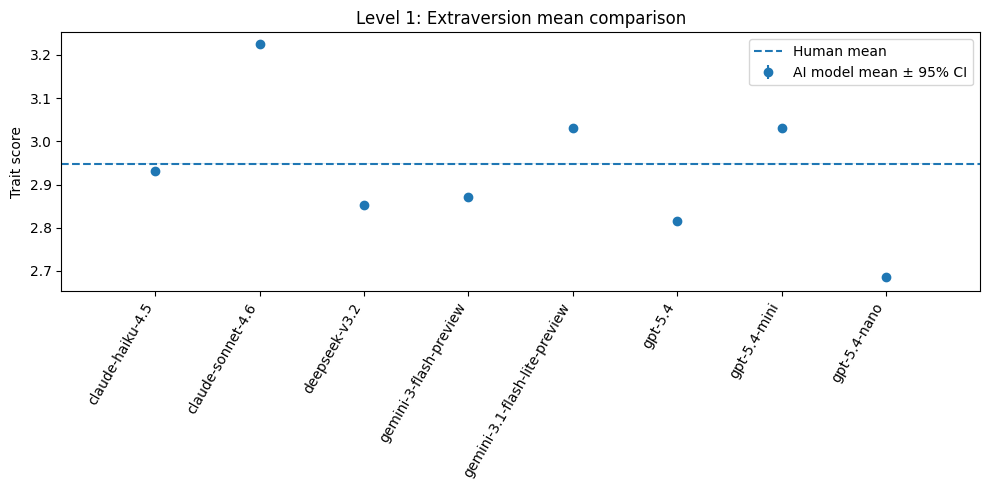

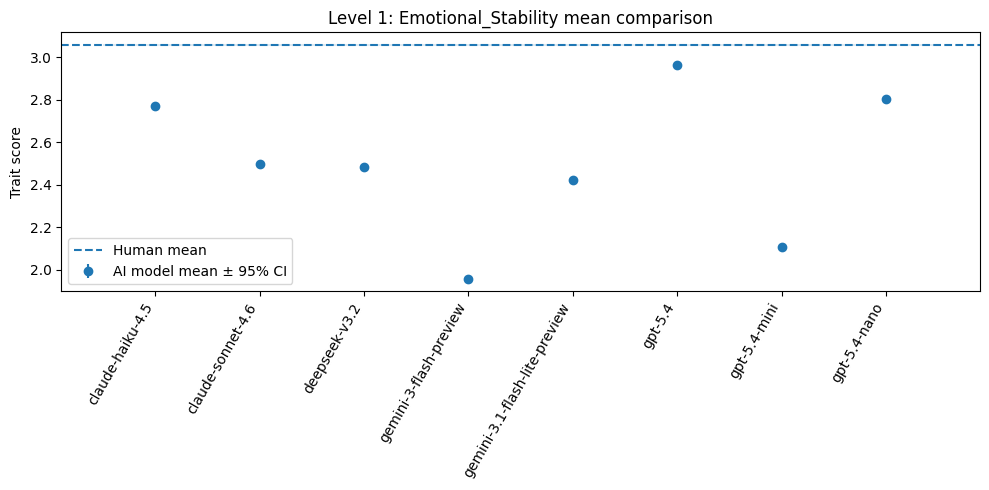

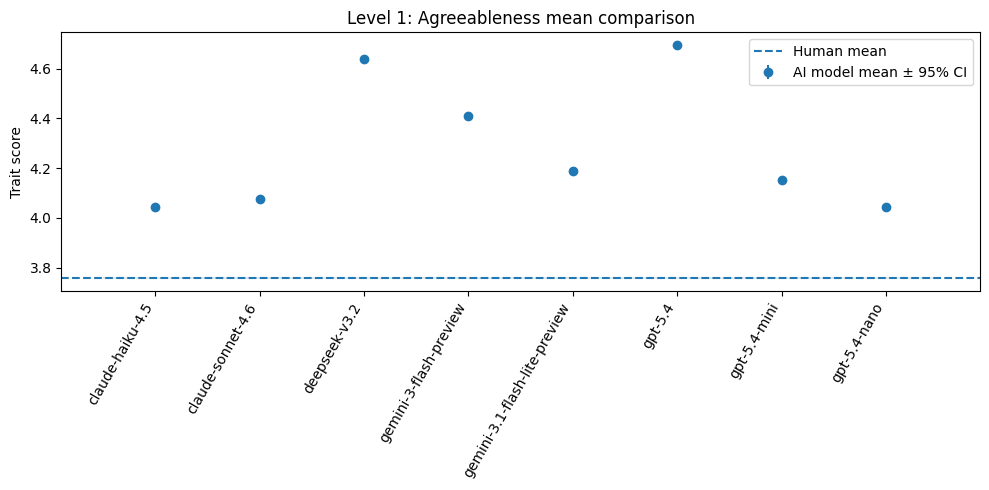

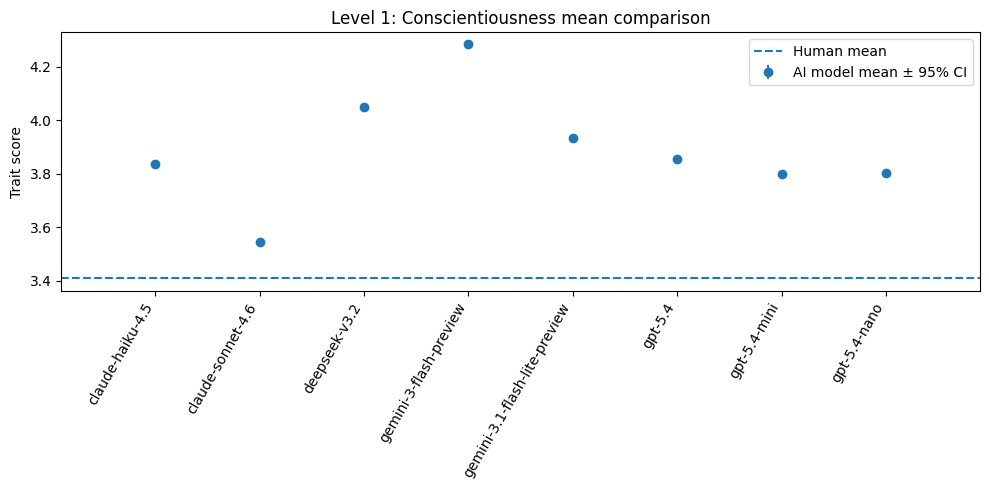

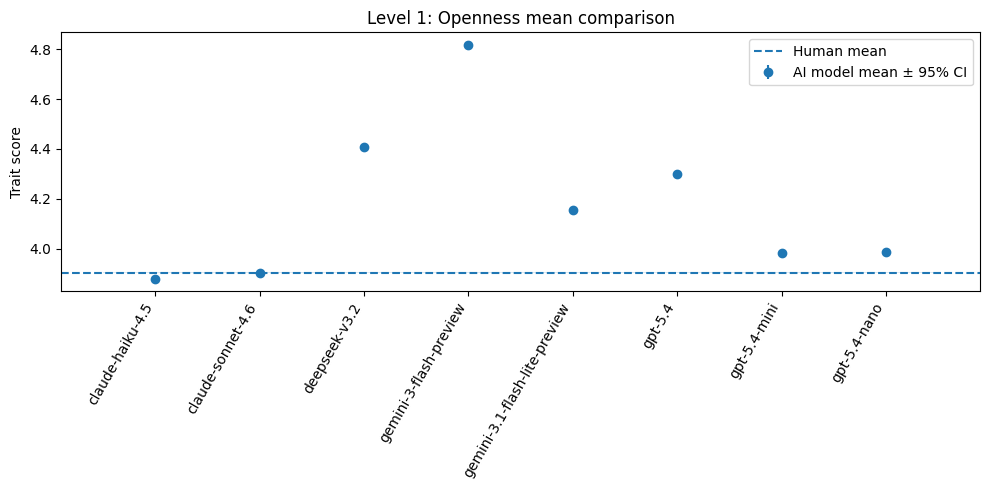

In [ ]:

# Figure: human vs model means with 95% CI
for trait in TRAIT_PREFIXES:
    fig, ax = plt.subplots(figsize=(10, 5))
    sub = central_table.loc[central_table["trait"] == trait].copy()
    x = np.arange(len(sub))
    ax.errorbar(
        x,
        sub["ai_mean"],
        yerr=1.96 * sub["ai_sd"] / np.sqrt(sub["ai_n"]),
        fmt='o',
        label="AI model mean ± 95% CI"
    )
    human_mean = sub["human_mean"].iloc[0]
    human_ci = 1.96 * sub["human_sd"].iloc[0] / np.sqrt(sub["human_n"].iloc[0])
    ax.axhline(human_mean, linestyle='--', label="Human mean")
    ax.fill_between([-0.5, len(sub)-0.5], human_mean-human_ci, human_mean+human_ci, alpha=0.15)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["model"], rotation=60, ha="right")
    ax.set_title(f"Level 1: {trait} mean comparison")
    ax.set_ylabel("Trait score")
    ax.legend()
    plt.tight_layout()
    save_fig(fig, f"level1_{trait}_mean_comparison")
    plt.show()



# Level 2 — Distribution fidelity

**Question:** Even if means are similar, do the full distributions match?

### Tests used
- Wasserstein distance
- Energy distance
- permutation p-value for Wasserstein
- Kolmogorov–Smirnov test
- Brown–Forsythe variance test
- skewness and kurtosis differences


In [ ]:

def maybe_downsample(x, max_n, rng):
    x = np.asarray(x)
    if len(x) <= max_n:
        return x
    idx = rng.choice(len(x), size=max_n, replace=False)
    return x[idx]

dist_rows = []
rng = np.random.default_rng(42)

for model_name, model_df in ai_scored.groupby("model"):
    for trait in TRAIT_PREFIXES:
        hx = human_scored[trait].to_numpy()
        ax = model_df[trait].to_numpy()

        hx_s = maybe_downsample(hx, MAX_N_PER_GROUP_FOR_DIST_TESTS, rng)
        ax_s = maybe_downsample(ax, MAX_N_PER_GROUP_FOR_DIST_TESTS, rng)

        w_obs, w_p = permutation_pvalue_distance(hx_s, ax_s, wasserstein_distance, n_perm=N_PERM, seed=42)
        e_obs = energy_distance(hx_s, ax_s)
        ks = ks_2samp(hx_s, ax_s, alternative="two-sided", method="asymp")
        bf = brown_forsythe(hx_s, ax_s)

        dist_rows.append({
            "model": model_name,
            "trait": trait,
            "human_n_used": len(hx_s),
            "ai_n_used": len(ax_s),
            "wasserstein": w_obs,
            "wasserstein_perm_p": w_p,
            "energy_distance": e_obs,
            "ks_stat": ks.statistic,
            "ks_p": ks.pvalue,
            "brown_forsythe_stat": bf.statistic,
            "brown_forsythe_p": bf.pvalue,
            "human_skew": stats.skew(hx_s, bias=False),
            "ai_skew": stats.skew(ax_s, bias=False),
            "human_kurtosis": stats.kurtosis(hx_s, fisher=True, bias=False),
            "ai_kurtosis": stats.kurtosis(ax_s, fisher=True, bias=False),
        })

dist_table = pd.DataFrame(dist_rows)
dist_table["wasserstein_perm_p_fdr"] = multipletests(dist_table["wasserstein_perm_p"], method="fdr_bh")[1]
dist_table["ks_p_fdr"] = multipletests(dist_table["ks_p"], method="fdr_bh")[1]
dist_table["brown_forsythe_p_fdr"] = multipletests(dist_table["brown_forsythe_p"], method="fdr_bh")[1]
save_df(dist_table, "level2_distribution_fidelity")
display(dist_table.head(15))


,model,trait,human_n_used,ai_n_used,wasserstein,wasserstein_perm_p,energy_distance,ks_stat,ks_p,brown_forsythe_stat,brown_forsythe_p,human_skew,ai_skew,human_kurtosis,ai_kurtosis,wasserstein_perm_p_fdr,ks_p_fdr,brown_forsythe_p_fdr
0,claude-haiku-4.5,Extraversion,5000,5000,0.20210,0.000999,0.298556,0.3618,1.175923e-293,4748.113756,0.000000e+00,-0.102272,0.154003,0.448053,-0.553144,0.000999,1.306581e-293,0.000000e+00
1,claude-haiku-4.5,Emotional_Stability,5000,5000,0.49210,0.000999,0.520911,0.5038,0.000000e+00,3085.791994,0.000000e+00,-0.126571,-0.851562,-0.560823,-0.734104,0.000999,0.000000e+00,0.000000e+00
2,claude-haiku-4.5,Agreeableness,5000,5000,0.54532,0.000999,0.558896,0.5158,0.000000e+00,5796.826468,0.000000e+00,-0.670784,-6.677037,0.316005,69.171621,0.000999,0.000000e+00,0.000000e+00
3,claude-haiku-4.5,Conscientiousness,5000,5000,0.54888,0.000999,0.645184,0.5904,0.000000e+00,5982.903636,0.000000e+00,-0.134064,-2.963797,-0.386993,9.309127,0.000999,0.000000e+00,0.000000e+00
4,claude-haiku-4.5,Openness,5000,5000,0.44316,0.000999,0.487195,0.4268,0.000000e+00,7113.937487,0.000000e+00,-0.423143,-4.534709,-0.056888,25.266031,0.000999,0.000000e+00,0.000000e+00
5,claude-sonnet-4.6,Extraversion,5000,5000,0.31390,0.000999,0.539539,0.7546,0.000000e+00,5682.989802,0.000000e+00,-0.124535,1.179976,0.348587,-0.491247,0.000999,0.000000e+00,0.000000e+00
6,claude-sonnet-4.6,Emotional_Stability,5000,5000,0.81998,0.000999,0.818823,0.7078,0.000000e+00,10137.103920,0.000000e+00,-0.039343,-10.467498,-0.604147,181.167389,0.000999,0.000000e+00,0.000000e+00
7,claude-sonnet-4.6,Agreeableness,5000,5000,0.55056,0.000999,0.572695,0.5602,0.000000e+00,6833.251604,0.000000e+00,-0.654722,1.035048,0.296517,3.727424,0.000999,0.000000e+00,0.000000e+00
8,claude-sonnet-4.6,Conscientiousness,5000,5000,0.42802,0.000999,0.489826,0.4784,0.000000e+00,7246.273284,0.000000e+00,-0.184495,1.748548,-0.333941,8.007874,0.000999,0.000000e+00,0.000000e+00
9,claude-sonnet-4.6,Openness,5000,5000,0.46920,0.000999,0.522915,0.4560,0.000000e+00,8656.067272,0.000000e+00,-0.443607,5.470674,0.179493,29.397121,0.000999,0.000000e+00,0.000000e+00


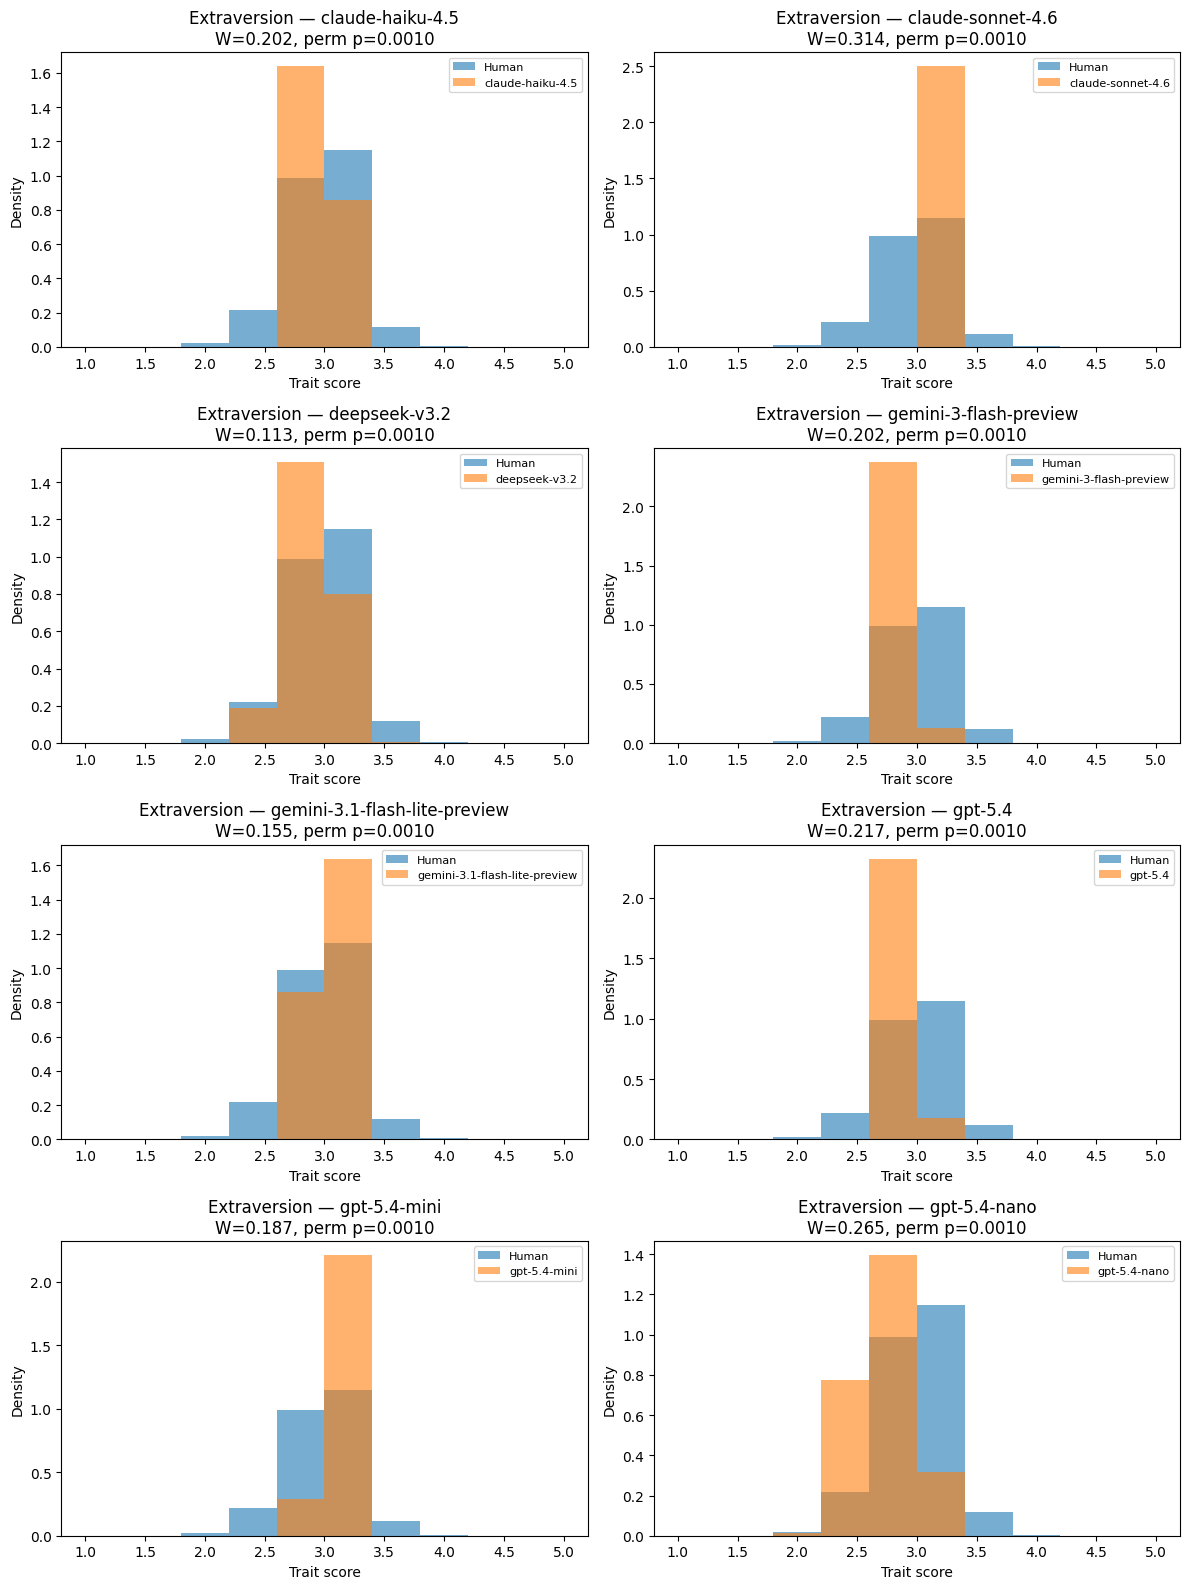

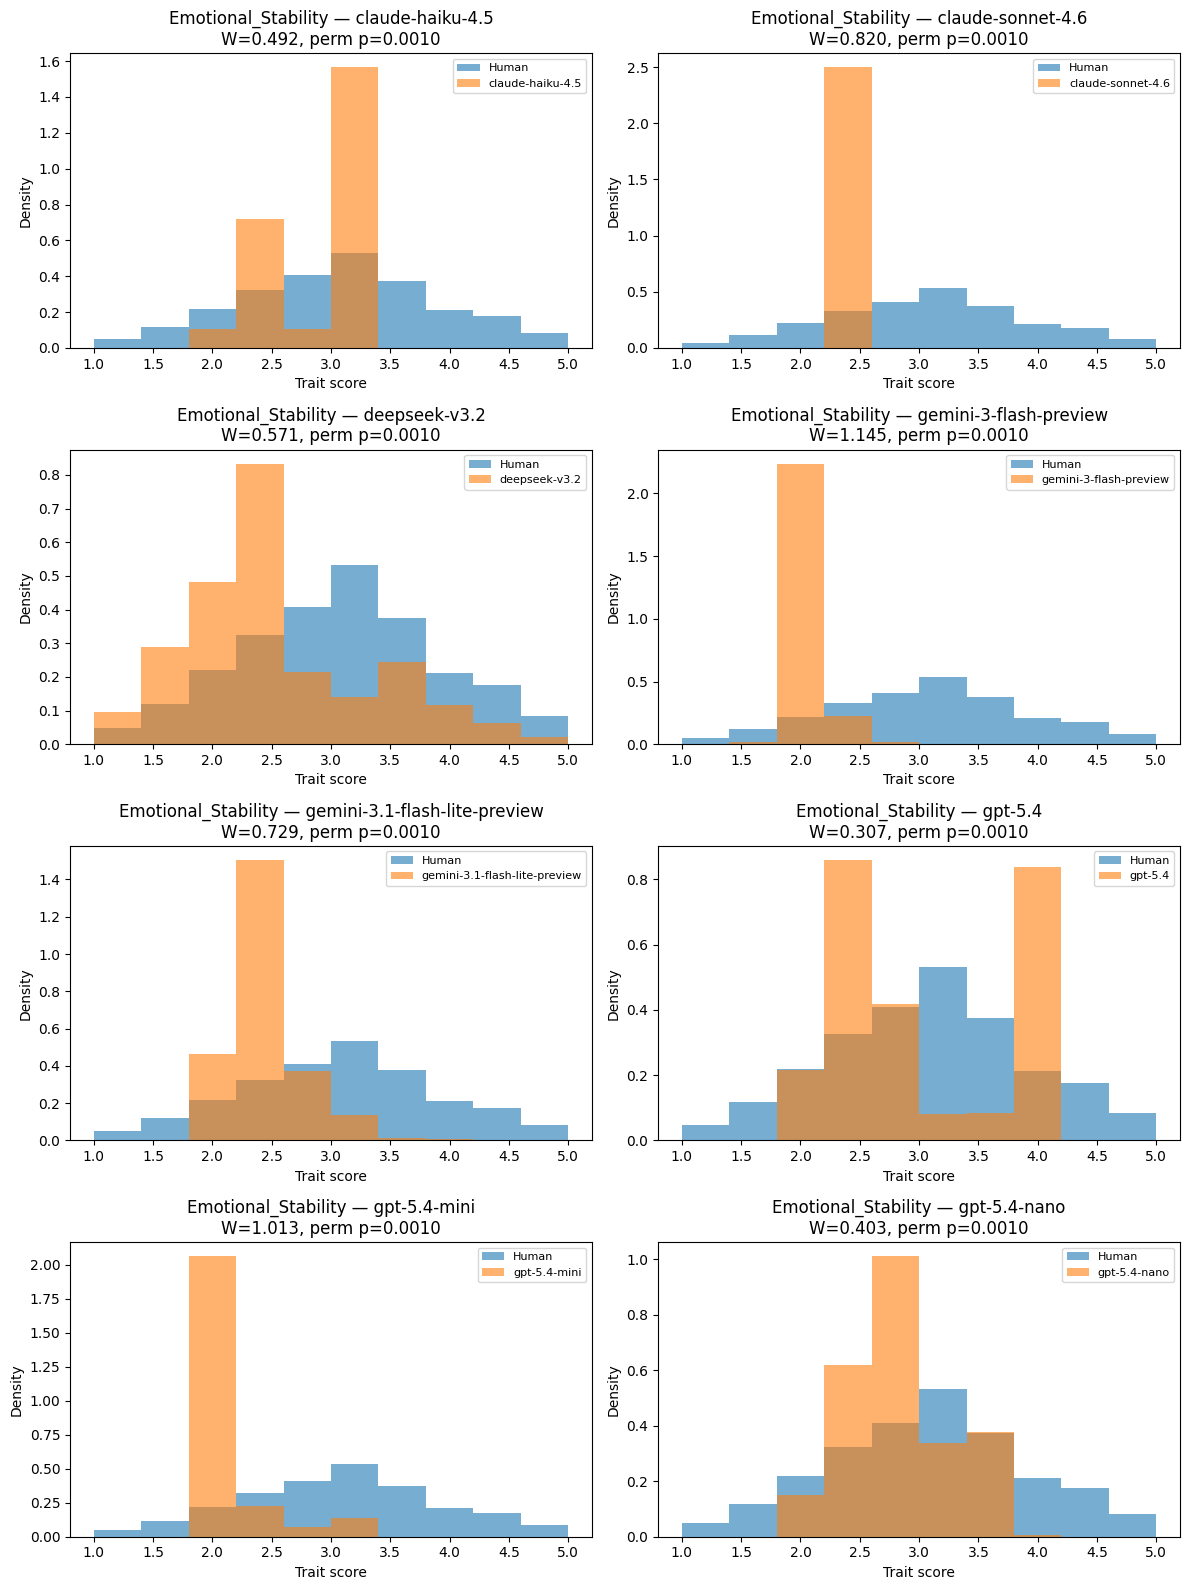

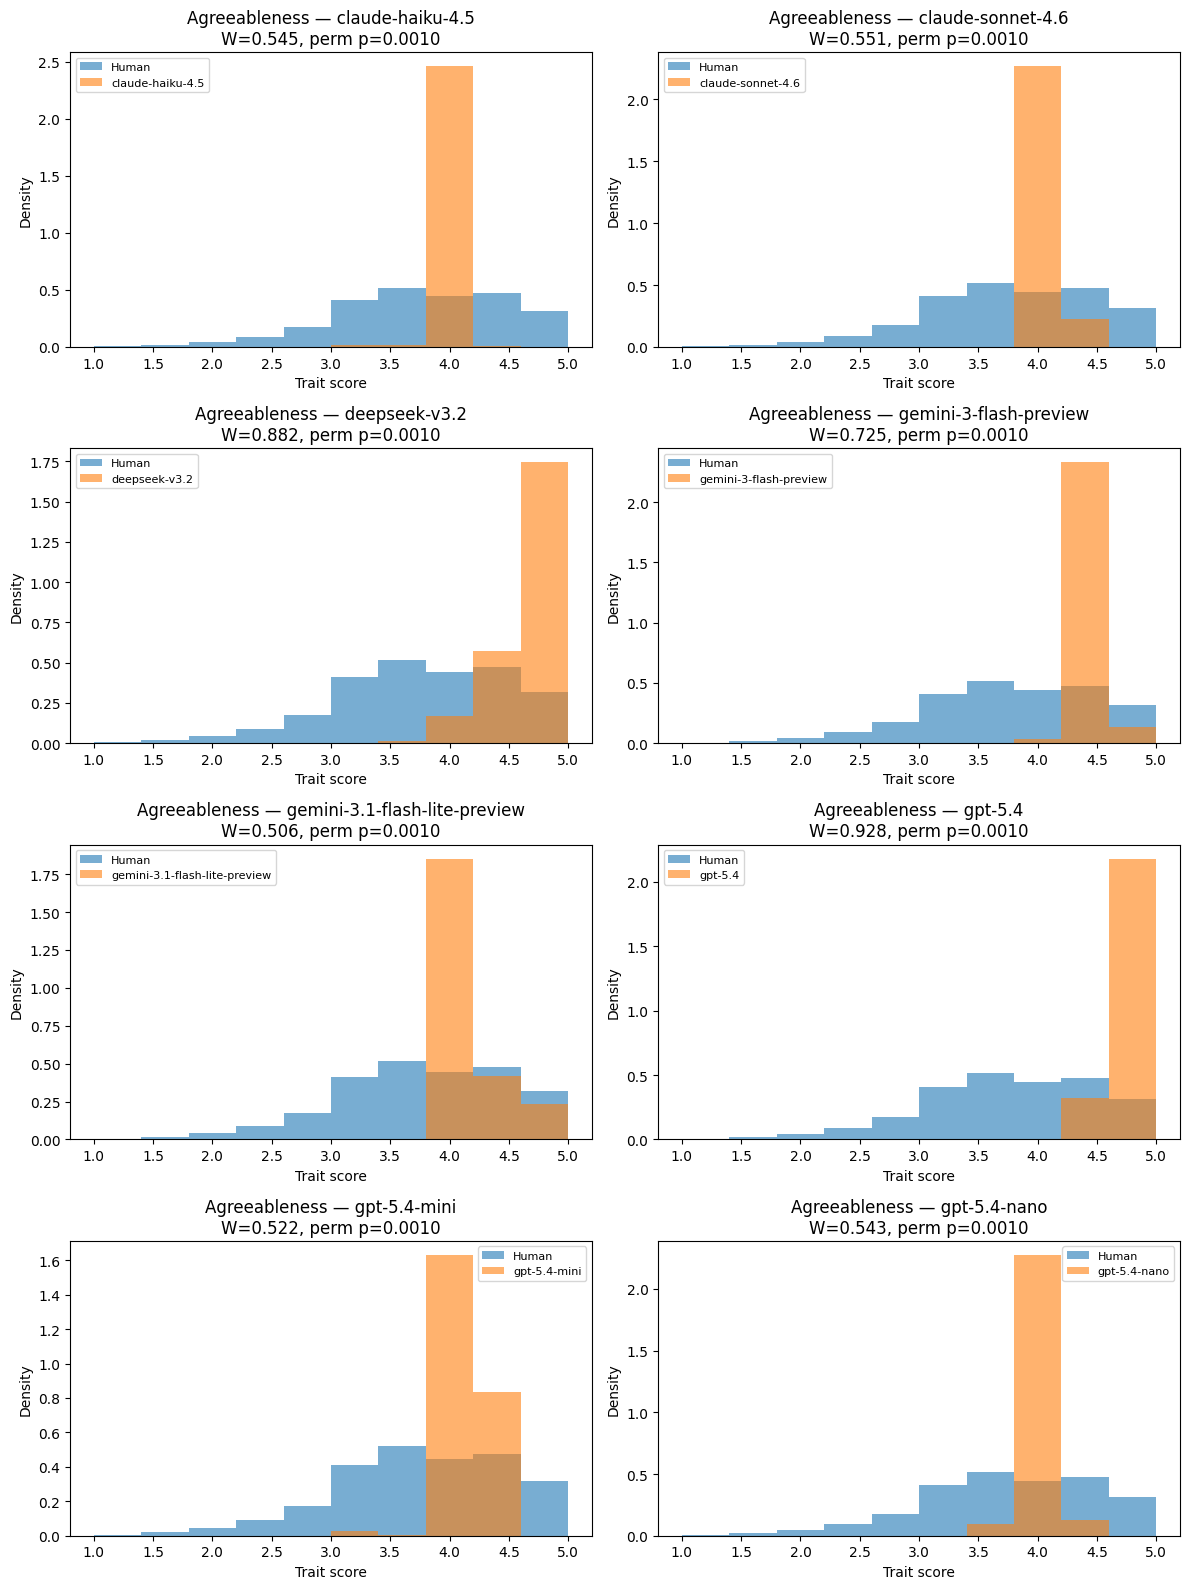

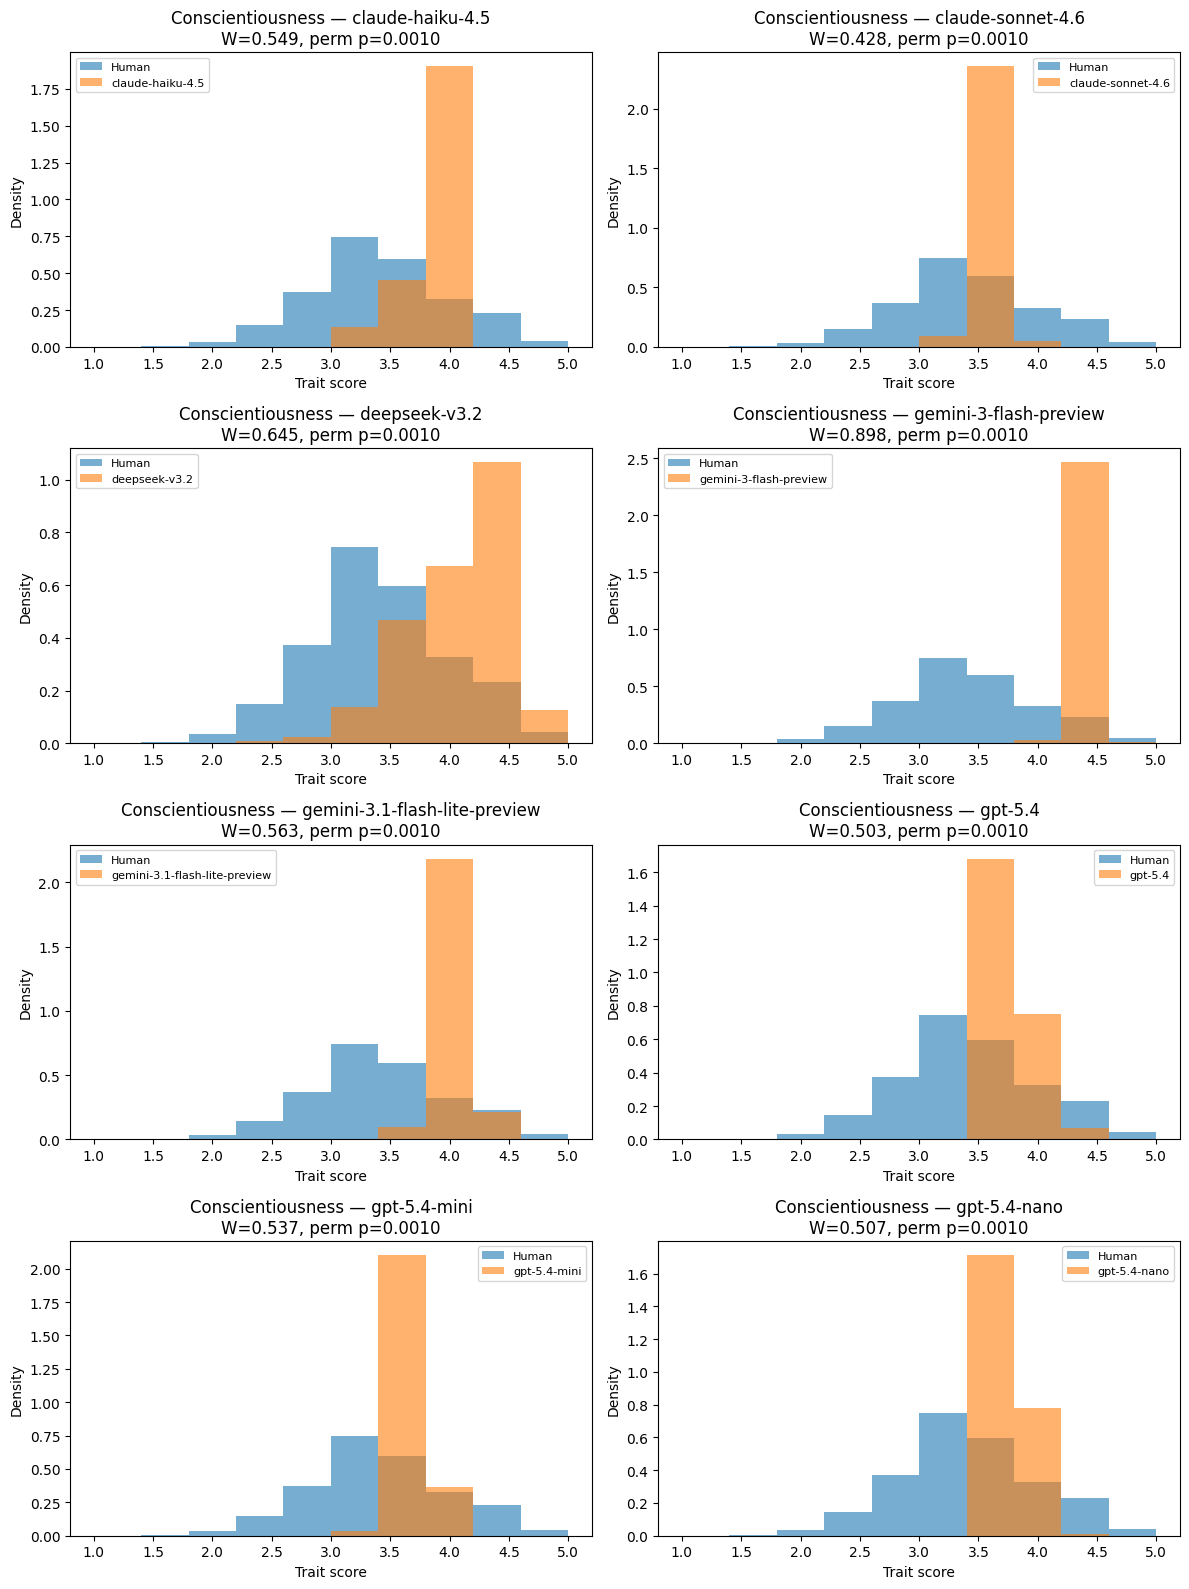

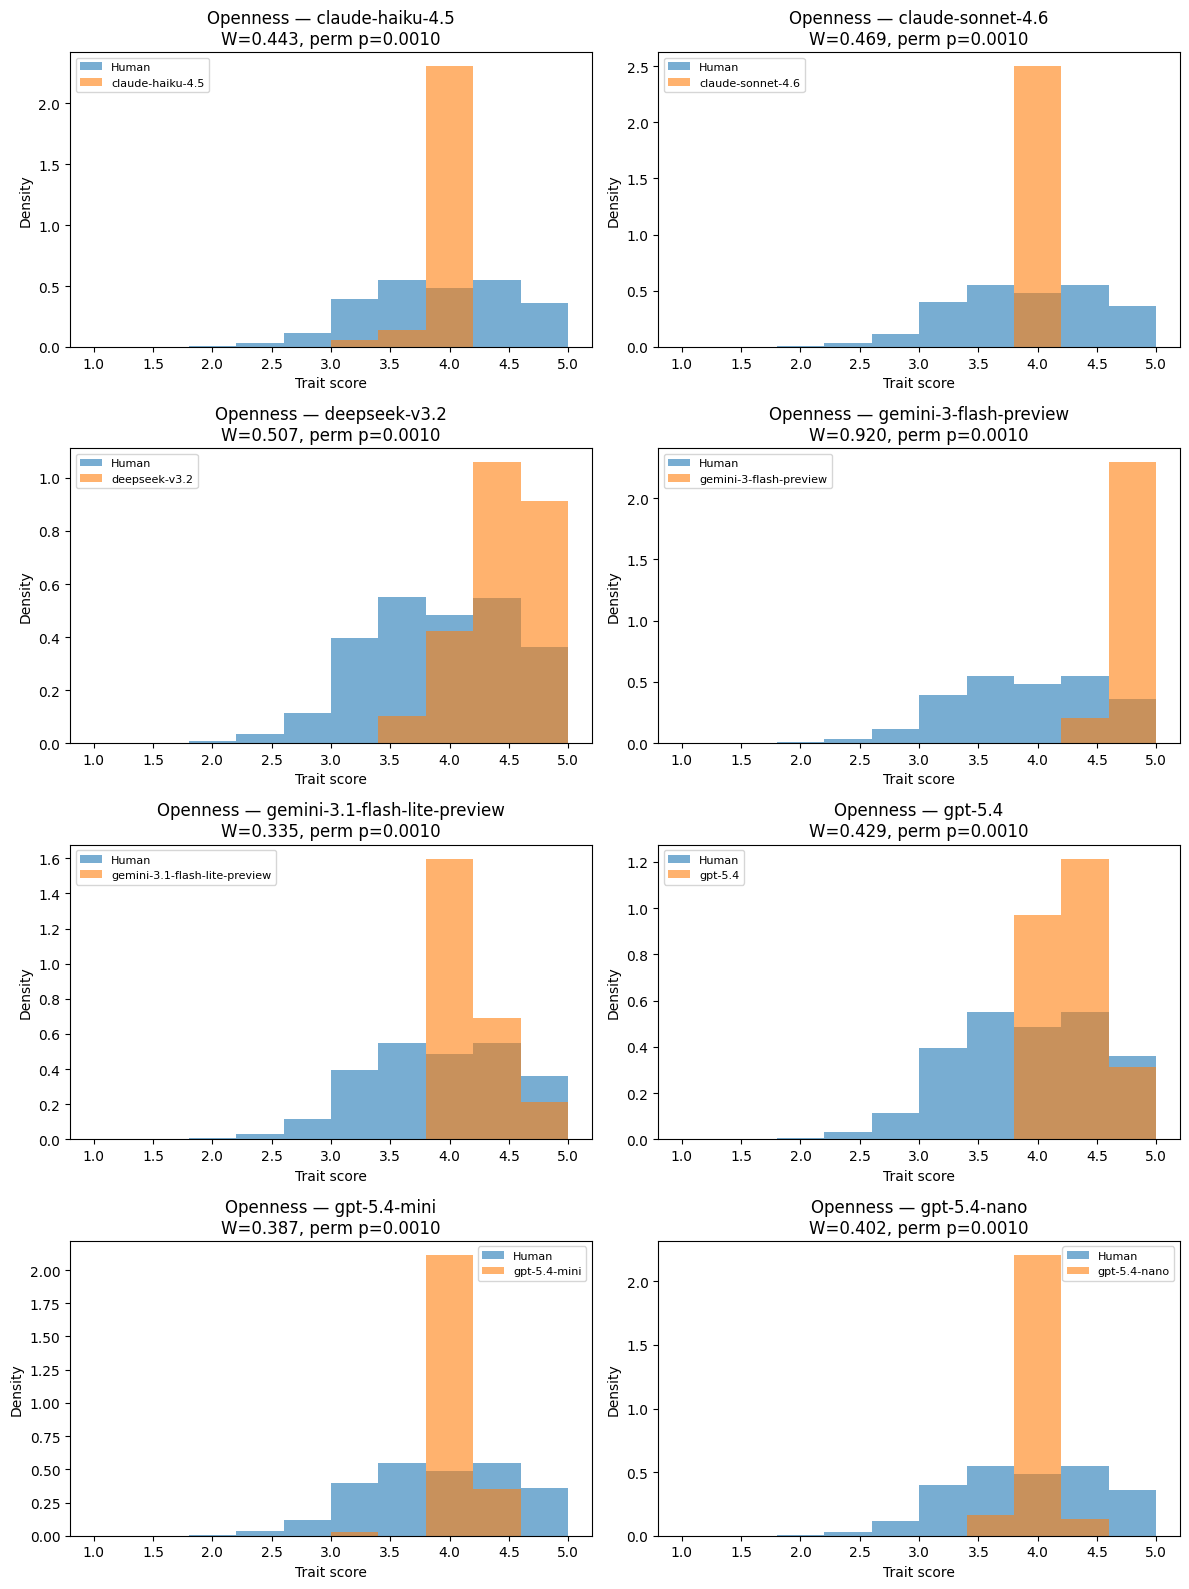

In [ ]:

# Figure: histograms for each trait and model overlayed against humans
for trait in TRAIT_PREFIXES:
    fig, axes = plt.subplots(nrows=math.ceil(ai_scored["model"].nunique() / 2), ncols=2, figsize=(12, 16))
    axes = np.array(axes).reshape(-1)
    bins = np.linspace(LIKERT_MIN, LIKERT_MAX, 11)

    for ax, (model_name, model_df) in zip(axes, ai_scored.groupby("model")):
        ax.hist(human_scored[trait], bins=bins, alpha=0.6, density=True, label="Human")
        ax.hist(model_df[trait], bins=bins, alpha=0.6, density=True, label=model_name)
        sub = dist_table[(dist_table["model"] == model_name) & (dist_table["trait"] == trait)].iloc[0]
        ax.set_title(f"{trait} — {model_name}\nW={sub['wasserstein']:.3f}, perm p={sub['wasserstein_perm_p']:.4f}")
        ax.set_xlabel("Trait score")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)

    for ax in axes[len(ai_scored['model'].unique()):]:
        ax.axis("off")

    plt.tight_layout()
    save_fig(fig, f"level2_{trait}_distribution_overlays")
    plt.show()


# Level 3 — Reliability fidelity

**Question:** Does AI show the same internal consistency as humans?

### Descriptive metrics used
- Cronbach's alpha
- McDonald's omega (one-factor estimate within each trait block)
- corrected item-total correlations
- alpha if item deleted

### Inferential additions in this revised notebook
- bootstrap confidence intervals for alpha and omega
- bootstrap confidence intervals for AI-minus-human differences in alpha and omega
- permutation tests for alpha and omega differences between each model and humans

The inferential layer is intentionally row-resampling based so the notebook remains practical in Colab.

In [23]:
def mcdonalds_omega_onefactor(df_items):
    # Filter out items with zero variance as they lead to singular matrices
    # and would cause issues in correlation matrix calculation.
    df_items_filtered = df_items.loc[:, df_items.var() > 0]

    # If after filtering, there are fewer than 2 items,
    # factor analysis for omega is not meaningful.
    if df_items_filtered.shape[1] < 2:
        return np.nan

    fa = FactorAnalyzer(n_factors=1, rotation=None, method="minres")
    try:
        fa.fit(df_items_filtered)
    except np.linalg.LinAlgError:
        # Catch LinAlgError if the correlation matrix is singular (e.g., perfect multicollinearity
        # among remaining items, or if the number of samples is too small for the items remaining
        # in some specific bootstrap/permutation iteration).
        return np.nan

    loadings = fa.loadings_.flatten()
    uniq = fa.get_uniquenesses()
    numerator = loadings.sum() ** 2
    denominator = numerator + uniq.sum()
    if denominator == 0:
        return np.nan
    return numerator / denominator

def alpha_if_item_deleted(df_items):
    rows = []
    for c in df_items.columns:
        alpha_del = cronbach_alpha_manual(df_items.drop(columns=[c]))
        rows.append({"item": c, "alpha_if_deleted": alpha_del})
    return pd.DataFrame(rows)

def alpha_stat(df):
    return cronbach_alpha_manual(df)

def omega_stat(df):
    return mcdonalds_omega_onefactor(df)

reliability_rows = []
itemtotal_rows = []
alpha_delete_rows = []
rel_infer_rows = []

# humans descriptive + inferential base
human_trait_items = {}
for trait, prefix in TRAIT_PREFIXES.items():
    cols = [f"{prefix}{i}" for i in range(1, 11)]
    items = human_scored[cols]
    human_trait_items[trait] = items.copy()
    alpha = cronbach_alpha_manual(items)
    omega = mcdonalds_omega_onefactor(items)

    alpha_ci_low, alpha_ci_high, _ = bootstrap_ci_rows(
        maybe_downsample_df(items, MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG),
        alpha_stat, n_boot=N_BOOT_L3, seed=42
    )
    omega_ci_low, omega_ci_high, _ = bootstrap_ci_rows(
        maybe_downsample_df(items, MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG),
        omega_stat, n_boot=N_BOOT_L3, seed=43
    )

    reliability_rows.append({
        "group": "Human", "model": "Human", "trait": trait,
        "alpha": alpha, "omega": omega,
        "alpha_ci_low": alpha_ci_low, "alpha_ci_high": alpha_ci_high,
        "omega_ci_low": omega_ci_low, "omega_ci_high": omega_ci_high,
    })
    itc = corrected_item_total_corr(items)
    for item, r in itc.items():
        itemtotal_rows.append({"group": "Human", "model": "Human", "trait": trait, "item": item, "corrected_item_total_r": r})
    aid = alpha_if_item_deleted(items)
    aid["group"] = "Human"
    aid["model"] = "Human"
    aid["trait"] = trait
    alpha_delete_rows.append(aid)

# AI models
for model_name, model_df in ai_scored.groupby("model"):
    for trait, prefix in TRAIT_PREFIXES.items():
        cols = [f"{prefix}{i}" for i in range(1, 11)]
        items = model_df[cols]
        alpha = cronbach_alpha_manual(items)
        omega = mcdonalds_omega_onefactor(items)

        items_ds = maybe_downsample_df(items, MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG)
        human_ds = maybe_downsample_df(human_trait_items[trait], MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG)

        alpha_ci_low, alpha_ci_high, _ = bootstrap_ci_rows(items_ds, alpha_stat, n_boot=N_BOOT_L3, seed=100)
        omega_ci_low, omega_ci_high, _ = bootstrap_ci_rows(items_ds, omega_stat, n_boot=N_BOOT_L3, seed=101)

        alpha_diff_obs, alpha_perm_p = permutation_pvalue_rows(
            human_ds, items_ds, alpha_stat, n_perm=N_PERM_L3, seed=102, alternative="two-sided"
        )
        omega_diff_obs, omega_perm_p = permutation_pvalue_rows(
            human_ds, items_ds, omega_stat, n_perm=N_PERM_L3, seed=103, alternative="two-sided"
        )
        alpha_diff_ci_low, alpha_diff_ci_high, _ = bootstrap_diff_ci_rows(
            human_ds, items_ds, alpha_stat, n_boot=N_BOOT_L3, seed=104
        )
        omega_diff_ci_low, omega_diff_ci_high, _ = bootstrap_diff_ci_rows(
            human_ds, items_ds, omega_stat, n_boot=N_BOOT_L3, seed=105
        )

        reliability_rows.append({
            "group": "AI", "model": model_name, "trait": trait,
            "alpha": alpha, "omega": omega,
            "alpha_ci_low": alpha_ci_low, "alpha_ci_high": alpha_ci_high,
            "omega_ci_low": omega_ci_high if False else omega_ci_low, "omega_ci_high": omega_ci_high,
        })

        rel_infer_rows.append({
            "model": model_name,
            "trait": trait,
            "n_used_human": len(human_ds),
            "n_used_ai": len(items_ds),
            "alpha_diff_ai_minus_human": alpha_diff_obs,
            "alpha_diff_ci_low": alpha_diff_ci_low,
            "alpha_diff_ci_high": alpha_diff_ci_high,
            "alpha_perm_p": alpha_perm_p,
            "omega_diff_ai_minus_human": omega_diff_obs,
            "omega_diff_ci_low": omega_diff_ci_low,
            "omega_diff_ci_high": omega_diff_ci_high,
            "omega_perm_p": omega_perm_p,
        })

        itc = corrected_item_total_corr(items)
        for item, r in itc.items():
            itemtotal_rows.append({"group": "AI", "model": model_name, "trait": trait,
                                   "item": item, "corrected_item_total_r": r})
        aid = alpha_if_item_deleted(items)
        aid["group"] = "AI"
        aid["model"] = model_name
        aid["trait"] = trait
        alpha_delete_rows.append(aid)

reliability_table = pd.DataFrame(reliability_rows)
itemtotal_table = pd.DataFrame(itemtotal_rows)
alpha_deleted_table = pd.concat(alpha_delete_rows, ignore_index=True)
rel_infer_table = pd.DataFrame(rel_infer_rows)

if len(rel_infer_table):
    rel_infer_table["alpha_perm_p_fdr"] = multipletests(rel_infer_table["alpha_perm_p"], method="fdr_bh")[1]
    rel_infer_table["omega_perm_p_fdr"] = multipletests(rel_infer_table["omega_perm_p"], method="fdr_bh")[1]

# Human-vs-model reliability comparison view
rel_compare = reliability_table.merge(
    reliability_table.loc[reliability_table["group"] == "Human",
                          ["trait", "alpha", "omega", "alpha_ci_low", "alpha_ci_high", "omega_ci_low", "omega_ci_high"]]
    .rename(columns={
        "alpha": "human_alpha",
        "omega": "human_omega",
        "alpha_ci_low": "human_alpha_ci_low",
        "alpha_ci_high": "human_alpha_ci_high",
        "omega_ci_low": "human_omega_ci_low",
        "omega_ci_high": "human_omega_ci_high",
    }),
    on="trait",
    how="left"
)
rel_compare["alpha_diff_ai_minus_human"] = rel_compare["alpha"] - rel_compare["human_alpha"]
rel_compare["omega_diff_ai_minus_human"] = rel_compare["omega"] - rel_compare["human_omega"]
rel_compare = rel_compare.loc[rel_compare["group"] == "AI"].sort_values(["trait", "model"]).reset_index(drop=True)

if len(rel_infer_table):
    rel_compare = rel_compare.merge(
        rel_infer_table,
        on=["model", "trait", "alpha_diff_ai_minus_human", "omega_diff_ai_minus_human"],
        how="left"
    )

save_df(reliability_table, "level3_reliability_raw")
save_df(rel_compare, "level3_reliability_model_vs_human")
save_df(rel_infer_table, "level3_reliability_inferential")
save_df(itemtotal_table, "level3_item_total_correlations")
save_df(alpha_deleted_table, "level3_alpha_if_item_deleted")

display(rel_compare.head(15))

,group,model,trait,alpha,omega,alpha_ci_low,alpha_ci_high,omega_ci_low,omega_ci_high,human_alpha,human_omega,human_alpha_ci_low,human_alpha_ci_high,human_omega_ci_low,human_omega_ci_high,alpha_diff_ai_minus_human,omega_diff_ai_minus_human,n_used_human,n_used_ai,alpha_diff_ci_low,alpha_diff_ci_high,alpha_perm_p,omega_diff_ci_low,omega_diff_ci_high,omega_perm_p,alpha_perm_p_fdr,omega_perm_p_fdr
0,AI,claude-haiku-4.5,Agreeableness,0.680418,NaN,0.670628,0.838488,0.923840,0.957954,0.852490,0.859966,0.837072,0.863217,0.846680,0.871139,-0.172072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AI,claude-sonnet-4.6,Agreeableness,0.067990,0.647070,-0.054477,0.161714,0.569602,0.744096,0.852490,0.859966,0.837072,0.863217,0.846680,0.871139,-0.784500,-0.212896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AI,deepseek-v3.2,Agreeableness,0.825225,0.832767,0.816315,0.840410,0.821774,0.850586,0.852490,0.859966,0.837072,0.863217,0.846680,0.871139,-0.027265,-0.027200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AI,gemini-3-flash-preview,Agreeableness,0.698036,0.675324,0.666930,0.705849,0.682049,0.729910,0.852490,0.859966,0.837072,0.863217,0.846680,0.871139,-0.154454,-0.184642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AI,gemini-3.1-flash-lite-preview,Agreeableness,0.879537,0.894135,0.872813,0.893362,0.886313,0.908050,0.852490,0.859966,0.837072,0.863217,0.846680,0.871139,0.027046,0.034169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AI,gpt-5.4,Agreeableness,0.554789,0.556548,0.536977,0.580340,0.565149,0.638723,0.852490,0.859966,0.837072,0.863217,0.846680,0.871139,-0.297702,-0.303418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AI,gpt-5.4-mini,Agreeableness,0.836031,0.943408,0.718318,0.838156,0.903302,0.944371,0.852490,0.859966,0.837072,0.863217,0.846680,0.871139,-0.016460,0.083442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AI,gpt-5.4-nano,Agreeableness,0.269533,0.279561,0.218839,0.330463,0.308489,0.387272,0.852490,0.859966,0.837072,0.863217,0.846680,0.871139,-0.582957,-0.580405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AI,claude-haiku-4.5,Conscientiousness,0.913588,0.924773,0.907807,0.928999,0.921738,0.941195,0.834218,0.834418,0.822627,0.845983,0.826149,0.848568,0.079370,0.090355,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,AI,claude-sonnet-4.6,Conscientiousness,0.457886,NaN,0.354407,0.482888,NaN,NaN,0.834218,0.834418,0.822627,0.845983,0.826149,0.848568,-0.376332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


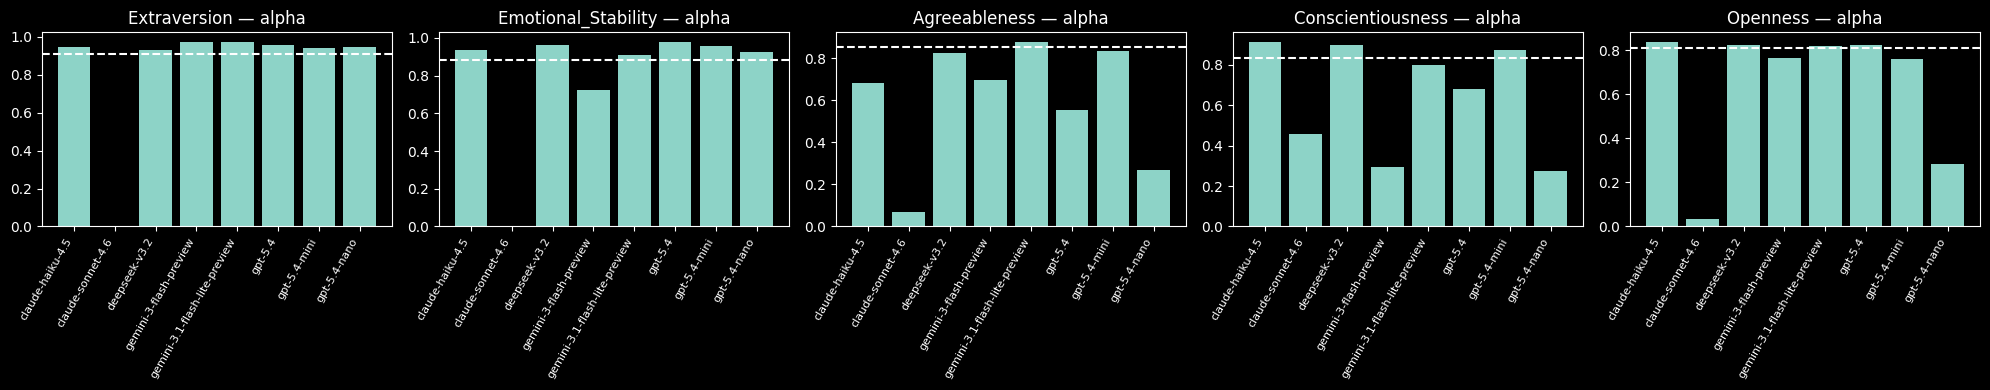

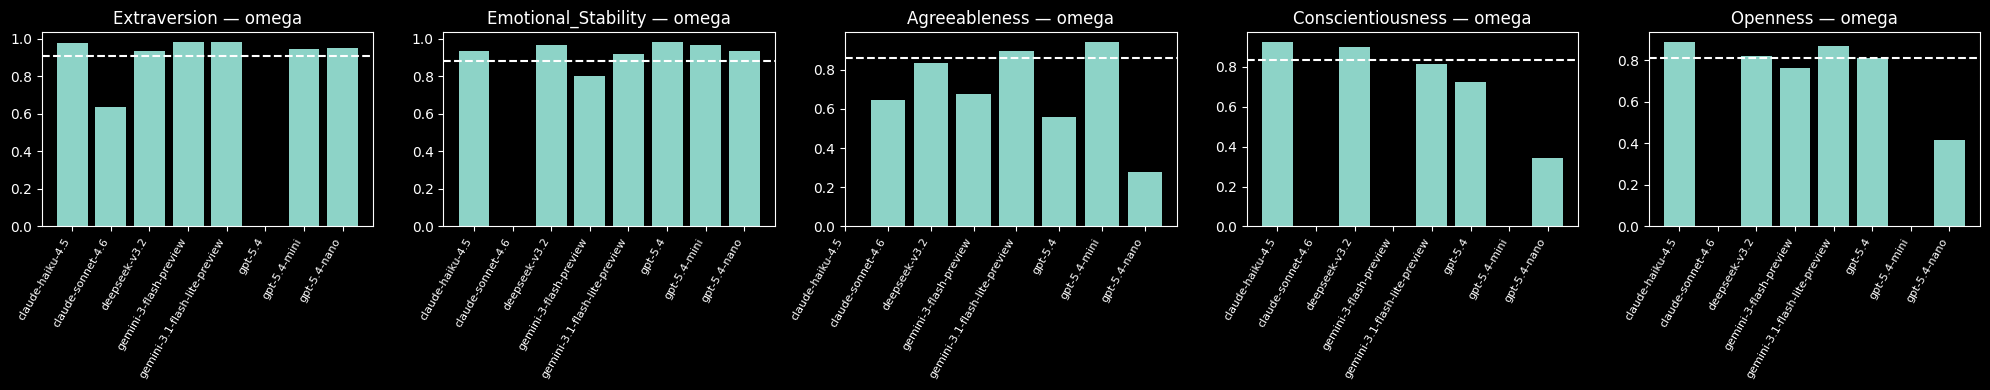

In [24]:

# Figure: alpha and omega by trait
for metric in ["alpha", "omega"]:
    fig, axes = plt.subplots(1, len(TRAIT_PREFIXES), figsize=(20, 4), sharey=False)
    if len(TRAIT_PREFIXES) == 1:
        axes = [axes]
    for ax, trait in zip(axes, TRAIT_PREFIXES):
        sub = reliability_table.loc[reliability_table["trait"] == trait].copy()
        ai_sub = sub.loc[sub["group"] == "AI"]
        human_val = sub.loc[sub["group"] == "Human", metric].iloc[0]
        ax.bar(np.arange(len(ai_sub)), ai_sub[metric])
        ax.axhline(human_val, linestyle="--")
        ax.set_xticks(np.arange(len(ai_sub)))
        ax.set_xticklabels(ai_sub["model"], rotation=60, ha="right", fontsize=8)
        ax.set_title(f"{trait} — {metric}")
    plt.tight_layout()
    save_fig(fig, f"level3_{metric}_comparison")
    plt.show()


# Level 4 — Structural fidelity

**Question:** Does AI reproduce the internal psychometric structure of human personality?

### Descriptive analyses used
- trait-level correlation matrix comparison
- item-level correlation matrix comparison
- exploratory factor analysis (5 factors)
- Tucker congruence of factor loading matrices versus humans

### Inferential additions in this revised notebook
- bootstrap confidence intervals for trait-correlation and item-correlation similarity
- permutation tests for Frobenius-distance departures in trait and item correlation structure
- bootstrap confidence intervals for Tucker-style loading congruence summaries
- permutation tests for Tucker discrepancy where stable factor recovery is available

This notebook still prioritizes **EFA-based structure comparison** rather than full multi-group CFA, because it is more robust and practical in Colab.

In [ ]:
def corr_frobenius(a, b):
    return np.sqrt(((a - b) ** 2).to_numpy().sum())

def matrix_upper_tri_vector(df_corr):
    m = df_corr.to_numpy()
    idx = np.triu_indices_from(m, k=1)
    return m[idx]

def factor_loadings(df_items, n_factors=5):
    fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax", method="minres")
    try:
        fa.fit(df_items)
        load = pd.DataFrame(
            fa.loadings_,
            index=df_items.columns,
            columns=[f"F{i+1}" for i in range(n_factors)]
        )
    except (np.linalg.LinAlgError, ValueError):
        load = pd.DataFrame(np.nan, index=df_items.columns, columns=[f"F{i+1}" for i in range(n_factors)])
        fa.get_factor_variance = lambda: (np.zeros(n_factors), np.zeros(n_factors), np.zeros(n_factors))
    return load, fa

def tucker_congruence(load_a, load_b):
    A = load_a.copy()
    B = load_b.copy()
    scores = np.zeros((A.shape[1], B.shape[1]))
    for i, ca in enumerate(A.columns):
        for j, cb in enumerate(B.columns):
            a = A[ca].to_numpy()
            b = B[cb].to_numpy()
            # Handle NaNs that might have been returned by factor_loadings
            if np.isnan(a).any() or np.isnan(b).any():
                scores[i, j] = np.nan
                continue
            denom = np.sqrt((a**2).sum() * (b**2).sum())
            scores[i, j] = np.nan if denom == 0 else np.dot(a, b) / denom
    return pd.DataFrame(scores, index=A.columns, columns=B.columns)

def trait_corr_similarity_from_scored(df):
    corr = df[list(TRAIT_PREFIXES.keys())].corr()
    vec_h = matrix_upper_tri_vector(human_trait_corr)
    vec_m = matrix_upper_tri_vector(corr)
    return np.corrcoef(vec_h, vec_m)[0, 1]

def item_corr_similarity_from_scored(df):
    corr = df[ITEM_COLS].corr()
    vec_h = matrix_upper_tri_vector(human_item_corr)
    vec_m = matrix_upper_tri_vector(corr)
    return np.corrcoef(vec_h, vec_m)[0, 1]

def trait_corr_frob_stat(df):
    return corr_frobenius(human_trait_corr, df[list(TRAIT_PREFIXES.keys())].corr())

def item_corr_frob_stat(df):
    return corr_frobenius(human_item_corr, df[ITEM_COLS].corr())

def mean_abs_tucker_stat(df):
    model_loadings, _ = factor_loadings(df[ITEM_COLS], n_factors=5)
    congr = tucker_congruence(human_loadings, model_loadings)
    return np.nanmean(np.abs(congr.to_numpy()))

human_trait_corr = human_scored[list(TRAIT_PREFIXES.keys())].corr()
human_item_corr = human_scored[ITEM_COLS].corr()
human_loadings, human_fa = factor_loadings(human_scored[ITEM_COLS], n_factors=5)

struct_rows = []
congruence_tables = {}
struct_infer_rows = []

for model_name, model_df in ai_scored.groupby("model"):
    model_trait_corr = model_df[list(TRAIT_PREFIXES.keys())].corr()
    model_item_corr = model_df[ITEM_COLS].corr()

    trait_frob = corr_frobenius(human_trait_corr, model_trait_corr)
    item_frob = corr_frobenius(human_item_corr, model_item_corr)

    trait_vec_h = matrix_upper_tri_vector(human_trait_corr)
    trait_vec_m = matrix_upper_tri_vector(model_trait_corr)
    item_vec_h = matrix_upper_tri_vector(human_item_corr)
    item_vec_m = matrix_upper_tri_vector(model_item_corr)

    trait_mat_r = np.corrcoef(trait_vec_h, trait_vec_m)[0, 1]
    item_mat_r = np.corrcoef(item_vec_h, item_vec_m)[0, 1]

    model_loadings, model_fa = factor_loadings(model_df[ITEM_COLS], n_factors=5)
    congr = tucker_congruence(human_loadings, model_loadings)
    congruence_tables[model_name] = congr

    struct_rows.append({
        "model": model_name,
        "trait_corr_frobenius": trait_frob,
        "trait_corr_matrix_r": trait_mat_r,
        "item_corr_frobenius": item_frob,
        "item_corr_matrix_r": item_mat_r,
        "human_variance_explained_5f": human_fa.get_factor_variance()[1].sum(),
        "model_variance_explained_5f": model_fa.get_factor_variance()[1].sum(),
        "mean_abs_tucker_congruence": np.nanmean(np.abs(congr.to_numpy())),
        "max_abs_tucker_congruence": np.nanmax(np.abs(congr.to_numpy())),
    })

    human_ds = maybe_downsample_df(human_scored, MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG)
    model_ds = maybe_downsample_df(model_df, MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG)

    trait_r_ci_low, trait_r_ci_high, _ = bootstrap_diff_ci_rows(
        human_ds, model_ds, trait_corr_similarity_from_scored, n_boot=1, seed=0
    )  # placeholder to keep variable names defined

    # bootstrap observed-similarity CIs on the model sample relative to the fixed human reference
    trait_r_ci_low, trait_r_ci_high, _ = bootstrap_ci_rows(
        model_ds, trait_corr_similarity_from_scored, n_boot=N_BOOT_L4, seed=200
    )
    item_r_ci_low, item_r_ci_high, _ = bootstrap_ci_rows(
        model_ds, item_corr_similarity_from_scored, n_boot=N_BOOT_L4, seed=201
    )
    tucker_ci_low, tucker_ci_high, _ = bootstrap_ci_rows(
        model_ds, mean_abs_tucker_stat, n_boot=N_BOOT_L4, seed=202
    )

    trait_frob_diff, trait_frob_perm_p = permutation_pvalue_rows(
        human_ds, model_ds, trait_corr_frob_stat, n_perm=N_PERM_L4, seed=203, alternative="greater"
    )
    item_frob_diff, item_frob_perm_p = permutation_pvalue_rows(
        human_ds, model_ds, item_corr_frob_stat, n_perm=N_PERM_L4, seed=204, alternative="greater"
    )
    tucker_diff, tucker_perm_p = permutation_pvalue_rows(
        human_ds, model_ds, mean_abs_tucker_stat, n_perm=N_PERM_L4, seed=205, alternative="greater"
    )

    struct_infer_rows.append({
        "model": model_name,
        "n_used_human": len(human_ds),
        "n_used_ai": len(model_ds),
        "trait_corr_matrix_r_ci_low": trait_r_ci_low,
        "trait_corr_matrix_r_ci_high": trait_r_ci_high,
        "item_corr_matrix_r_ci_low": item_r_ci_low,
        "item_corr_matrix_r_ci_high": item_r_ci_high,
        "mean_abs_tucker_ci_low": tucker_ci_low,
        "mean_abs_tucker_ci_high": tucker_ci_high,
        "trait_corr_frobenius_perm_stat_diff": trait_frob_diff,
        "trait_corr_frobenius_perm_p": trait_frob_perm_p,
        "item_corr_frobenius_perm_stat_diff": item_frob_diff,
        "item_corr_frobenius_perm_p": item_frob_perm_p,
        "mean_abs_tucker_perm_stat_diff": tucker_diff,
        "mean_abs_tucker_perm_p": tucker_perm_p,
    })

struct_table = pd.DataFrame(struct_rows).sort_values("model").reset_index(drop=True)
struct_infer_table = pd.DataFrame(struct_infer_rows).sort_values("model").reset_index(drop=True)

if len(struct_infer_table):
    struct_infer_table["trait_corr_frobenius_perm_p_fdr"] = multipletests(struct_infer_table["trait_corr_frobenius_perm_p"], method="fdr_bh")[1]
    struct_infer_table["item_corr_frobenius_perm_p_fdr"] = multipletests(struct_infer_table["item_corr_frobenius_perm_p"], method="fdr_bh")[1]
    struct_infer_table["mean_abs_tucker_perm_p_fdr"] = multipletests(struct_infer_table["mean_abs_tucker_perm_p"], method="fdr_bh")[1]
    struct_table = struct_table.merge(struct_infer_table, on="model", how="left")

save_df(struct_table, "level4_structural_fidelity_summary")
save_df(struct_infer_table, "level4_structural_fidelity_inferential")
display(struct_table)

,model,trait_corr_frobenius,trait_corr_matrix_r,item_corr_frobenius,item_corr_matrix_r,human_variance_explained_5f,model_variance_explained_5f,mean_abs_tucker_congruence,max_abs_tucker_congruence,n_used_human,n_used_ai,trait_corr_matrix_r_ci_low,trait_corr_matrix_r_ci_high,item_corr_matrix_r_ci_low,item_corr_matrix_r_ci_high,mean_abs_tucker_ci_low,mean_abs_tucker_ci_high,trait_corr_frobenius_perm_stat_diff,trait_corr_frobenius_perm_p,item_corr_frobenius_perm_stat_diff,item_corr_frobenius_perm_p,mean_abs_tucker_perm_stat_diff,mean_abs_tucker_perm_p,trait_corr_frobenius_perm_p_fdr,item_corr_frobenius_perm_p_fdr,mean_abs_tucker_perm_p_fdr
0,claude-haiku-4.5,1.234804,0.828178,13.131623,0.680159,0.421446,0.727554,0.301531,0.907825,1500,1500,0.806762,0.859369,0.644751,0.672484,0.289589,0.308105,1.069091,0.004975,12.345435,0.004975,-0.028239,1.000000,0.004975,0.004975,1.000000
1,claude-sonnet-4.6,1.009441,0.065473,NaN,NaN,0.421446,0.000000,NaN,NaN,1500,1500,-0.025945,0.198402,NaN,NaN,NaN,NaN,0.964839,0.004975,NaN,0.004975,NaN,0.004975,0.004975,0.004975,0.006633
2,deepseek-v3.2,1.231044,0.751155,8.990671,0.823837,0.421446,0.520843,0.412074,0.945033,1500,1500,0.687919,0.755366,0.808862,0.826500,0.406628,0.421155,1.179974,0.004975,7.842036,0.004975,0.082983,0.004975,0.004975,0.004975,0.006633
3,gemini-3-flash-preview,0.731452,0.369277,NaN,NaN,0.421446,0.000000,NaN,NaN,1500,1500,0.215414,0.474268,NaN,NaN,NaN,NaN,0.649127,0.004975,NaN,0.004975,NaN,0.004975,0.004975,0.004975,0.006633
4,gemini-3.1-flash-lite-preview,2.038228,0.530844,NaN,NaN,0.421446,0.000000,NaN,NaN,1500,1500,0.524910,0.570471,NaN,NaN,NaN,NaN,1.931285,0.004975,NaN,0.004975,NaN,0.004975,0.004975,0.004975,0.006633
5,gpt-5.4,1.063949,0.714830,NaN,NaN,0.421446,0.000000,NaN,NaN,1500,1500,0.656626,0.732288,NaN,NaN,NaN,NaN,0.954228,0.004975,NaN,0.004975,NaN,0.004975,0.004975,0.004975,0.006633
6,gpt-5.4-mini,1.835560,0.769861,18.822585,0.648781,0.421446,0.777854,0.337383,0.937542,1500,1500,0.746251,0.789918,0.634014,0.658119,0.337628,0.337628,1.788630,0.004975,18.862461,0.004975,NaN,0.004975,0.004975,0.004975,0.006633
7,gpt-5.4-nano,0.500796,0.664473,7.337320,0.704501,0.421446,0.332408,0.292988,0.949614,1500,1500,0.613417,0.768349,0.678962,0.702286,0.254052,0.279995,0.370158,0.004975,6.216304,0.004975,-0.064918,1.000000,0.004975,0.004975,1.000000


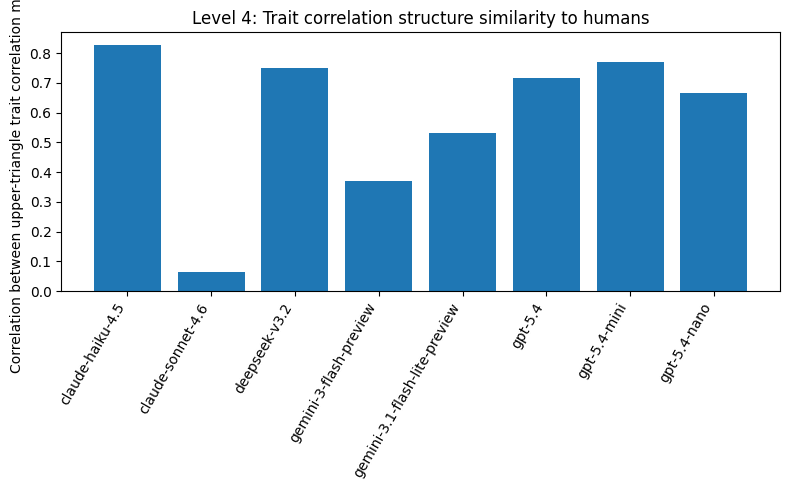

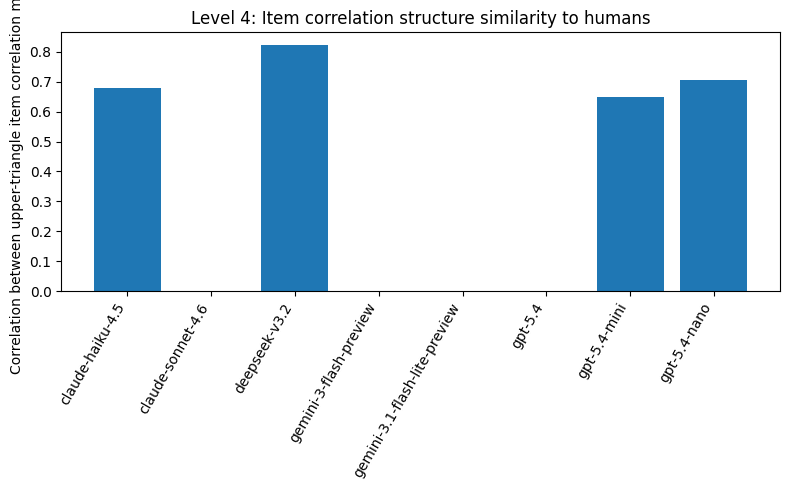

In [ ]:

# Figures: heatmaps of trait correlation matrices and item-correlation similarity summary
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
axes.bar(np.arange(len(struct_table)), struct_table["trait_corr_matrix_r"])
axes.set_xticks(np.arange(len(struct_table)))
axes.set_xticklabels(struct_table["model"], rotation=60, ha="right")
axes.set_ylabel("Correlation between upper-triangle trait correlation matrices")
axes.set_title("Level 4: Trait correlation structure similarity to humans")
plt.tight_layout()
save_fig(fig, "level4_trait_corr_similarity")
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(8, 5))
axes.bar(np.arange(len(struct_table)), struct_table["item_corr_matrix_r"])
axes.set_xticks(np.arange(len(struct_table)))
axes.set_xticklabels(struct_table["model"], rotation=60, ha="right")
axes.set_ylabel("Correlation between upper-triangle item correlation matrices")
axes.set_title("Level 4: Item correlation structure similarity to humans")
plt.tight_layout()
save_fig(fig, "level4_item_corr_similarity")
plt.show()


In [ ]:

# Optional: inspect one model's Tucker congruence matrix
example_model = struct_table["model"].iloc[0]
print("Example model for congruence matrix:", example_model)
display(congruence_tables[example_model])


Example model for congruence matrix: claude-haiku-4.5


,F1,F2,F3,F4,F5
F1,0.117054,0.907825,0.309841,-0.129185,-0.158542
F2,-0.090743,-0.127027,-0.175198,0.850135,0.697767
F3,0.699388,0.147752,0.200539,-0.116203,0.022077
F4,0.337352,0.143886,0.764993,-0.243651,-0.069329
F5,0.503172,0.169601,0.500525,-0.040468,-0.016033



# Level 5 — Behavioral fidelity

**Question:** Does AI answer like a human respondent?

### Analyses used
- response-option frequency comparison (chi-square, Cramér's V)
- acquiescence bias
- extreme response bias
- midpoint bias
- reverse-item sensitivity
- response entropy
- profile diversity in 5D trait space


In [ ]:

def response_option_counts(df, item_cols):
    vals = pd.Series(df[item_cols].to_numpy().ravel())
    counts = vals.value_counts().sort_index()
    counts = counts.reindex(range(LIKERT_MIN, LIKERT_MAX + 1), fill_value=0)
    return counts

def response_style_metrics(df, item_cols, reverse_cols):
    vals = df[item_cols].to_numpy().ravel()
    counts = pd.Series(vals).value_counts().sort_index().reindex(range(LIKERT_MIN, LIKERT_MAX + 1), fill_value=0)

    agree_prop = ((vals >= 4).sum()) / len(vals)
    extreme_prop = (((vals == LIKERT_MIN) | (vals == LIKERT_MAX)).sum()) / len(vals)
    midpoint = int(round((LIKERT_MIN + LIKERT_MAX) / 2))
    midpoint_prop = ((vals == midpoint).sum()) / len(vals)
    ent = shannon_entropy_from_counts(counts)

    forward_cols = [c for c in item_cols if c not in reverse_cols]
    reverse_cols_local = [c for c in item_cols if c in reverse_cols]

    forward_mean = df[forward_cols].to_numpy().mean() if forward_cols else np.nan
    reverse_mean_raw = df[reverse_cols_local].to_numpy().mean() if reverse_cols_local else np.nan
    reverse_mean_scored = reverse_code(df[reverse_cols_local], reverse_cols_local, LIKERT_MIN, LIKERT_MAX).to_numpy().mean() if reverse_cols_local else np.nan

    trait_profiles = df[list(TRAIT_PREFIXES.keys())].to_numpy()
    idx = np.arange(len(trait_profiles))
    if len(idx) > 2000:
        idx = RNG.choice(idx, size=2000, replace=False)
    sample = trait_profiles[idx]
    diffs = sample[:, None, :] - sample[None, :, :]
    dists = np.sqrt((diffs**2).sum(axis=2))
    tri = dists[np.triu_indices_from(dists, k=1)]
    mean_pairwise_profile_distance = tri.mean()

    return {
        "agree_prop": agree_prop,
        "extreme_prop": extreme_prop,
        "midpoint_prop": midpoint_prop,
        "response_entropy_bits": ent,
        "forward_mean_raw": forward_mean,
        "reverse_mean_raw": reverse_mean_raw,
        "reverse_mean_scored": reverse_mean_scored,
        "mean_pairwise_profile_distance": mean_pairwise_profile_distance,
    }

behavior_rows = []

human_counts = response_option_counts(human_scored, ITEM_COLS)
human_style = response_style_metrics(human_scored, ITEM_COLS, reverse_cols_flat)

for model_name, model_df in ai_scored.groupby("model"):
    model_counts = response_option_counts(model_df, ITEM_COLS)
    contingency = pd.DataFrame({"Human": human_counts, model_name: model_counts}).T
    chi2, p, dof, exp = stats.chi2_contingency(contingency)

    style = response_style_metrics(model_df, ITEM_COLS, reverse_cols_flat)

    behavior_rows.append({
        "model": model_name,
        "chi2_response_freq": chi2,
        "chi2_p": p,
        "cramers_v": cramers_v_from_table(contingency),
        "human_agree_prop": human_style["agree_prop"],
        "ai_agree_prop": style["agree_prop"],
        "human_extreme_prop": human_style["extreme_prop"],
        "ai_extreme_prop": style["extreme_prop"],
        "human_midpoint_prop": human_style["midpoint_prop"],
        "ai_midpoint_prop": style["midpoint_prop"],
        "human_entropy_bits": human_style["response_entropy_bits"],
        "ai_entropy_bits": style["response_entropy_bits"],
        "human_forward_mean_raw": human_style["forward_mean_raw"],
        "ai_forward_mean_raw": style["forward_mean_raw"],
        "human_reverse_mean_raw": human_style["reverse_mean_raw"],
        "ai_reverse_mean_raw": style["reverse_mean_raw"],
        "human_reverse_mean_scored": human_style["reverse_mean_scored"],
        "ai_reverse_mean_scored": style["reverse_mean_scored"],
        "human_mean_pairwise_profile_distance": human_style["mean_pairwise_profile_distance"],
        "ai_mean_pairwise_profile_distance": style["mean_pairwise_profile_distance"],
    })

behavior_table = pd.DataFrame(behavior_rows).sort_values("model").reset_index(drop=True)
behavior_table["chi2_p_fdr"] = multipletests(behavior_table["chi2_p"], method="fdr_bh")[1]
save_df(behavior_table, "level5_behavioral_fidelity")
display(behavior_table)


,model,chi2_response_freq,chi2_p,cramers_v,human_agree_prop,ai_agree_prop,human_extreme_prop,ai_extreme_prop,human_midpoint_prop,ai_midpoint_prop,human_entropy_bits,ai_entropy_bits,human_forward_mean_raw,ai_forward_mean_raw,human_reverse_mean_raw,ai_reverse_mean_raw,human_reverse_mean_scored,ai_reverse_mean_scored,human_mean_pairwise_profile_distance,ai_mean_pairwise_profile_distance,chi2_p_fdr
0,claude-haiku-4.5,243084.792156,0.0,0.182268,0.527681,0.536596,0.30528,0.038376,0.220571,0.380384,2.217236,1.509800,3.530026,3.527727,3.289599,3.453196,2.710401,2.546804,1.910823,0.447369,0.0
1,claude-sonnet-4.6,215521.016804,0.0,0.171623,0.527681,0.535706,0.30528,0.033068,0.220571,0.344276,2.217236,1.558182,3.530026,3.365773,3.289599,3.538654,2.710401,2.461346,1.910823,0.126505,0.0
2,deepseek-v3.2,35939.197308,0.0,0.070083,0.527681,0.628738,0.30528,0.347998,0.220571,0.158714,2.217236,2.090867,3.530026,3.812458,3.289599,3.551646,2.710401,2.448354,1.910823,1.263569,0.0
3,gemini-3-flash-preview,97643.077072,0.0,0.115518,0.527681,0.622574,0.30528,0.375984,0.220571,0.103128,2.217236,2.022921,3.530026,3.791238,3.289599,3.534283,2.710401,2.465717,1.910823,0.310224,0.0
4,gemini-3.1-flash-lite-preview,140737.343732,0.0,0.138687,0.527681,0.630712,0.30528,0.110870,0.220571,0.176914,2.217236,1.751728,3.530026,3.509531,3.289599,3.585567,2.710401,2.414433,1.910823,0.559605,0.0
5,gpt-5.4,82882.452253,0.0,0.106429,0.527681,0.673142,0.30528,0.247294,0.220571,0.132724,2.217236,1.869770,3.530026,3.844646,3.289599,3.597729,2.710401,2.402271,1.910823,0.972280,0.0
6,gpt-5.4-mini,302453.283272,0.0,0.203310,0.527681,0.642904,0.30528,0.048234,0.220571,0.080460,2.217236,1.463784,3.530026,3.381435,3.289599,3.449567,2.710401,2.550433,1.910823,0.384189,0.0
7,gpt-5.4-nano,234191.074870,0.0,0.178902,0.527681,0.627856,0.30528,0.042450,0.220571,0.179590,2.217236,1.564044,3.530026,3.617562,3.289599,3.297917,2.710401,2.702083,1.910823,0.679651,0.0


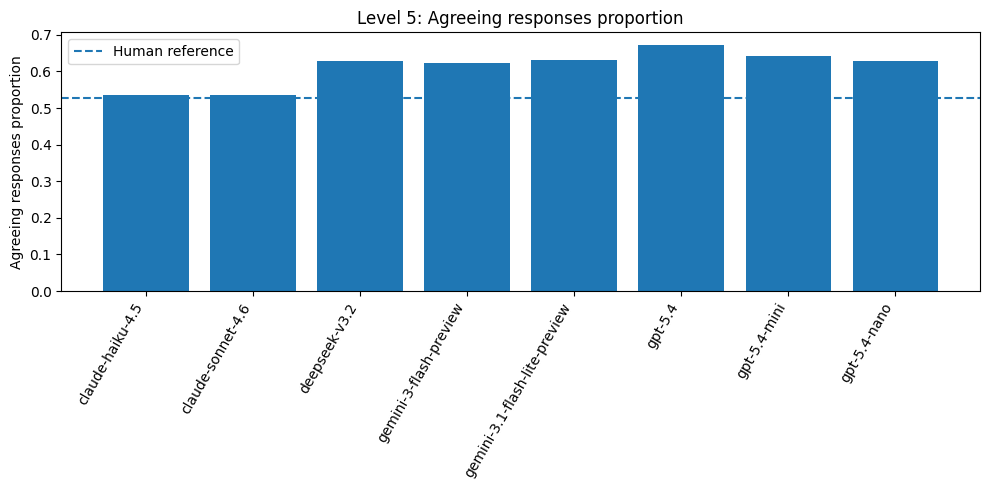

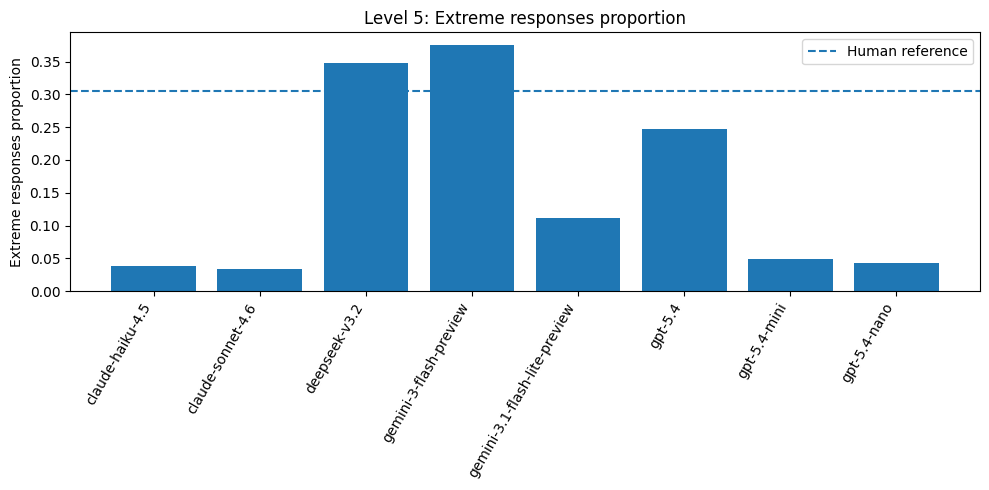

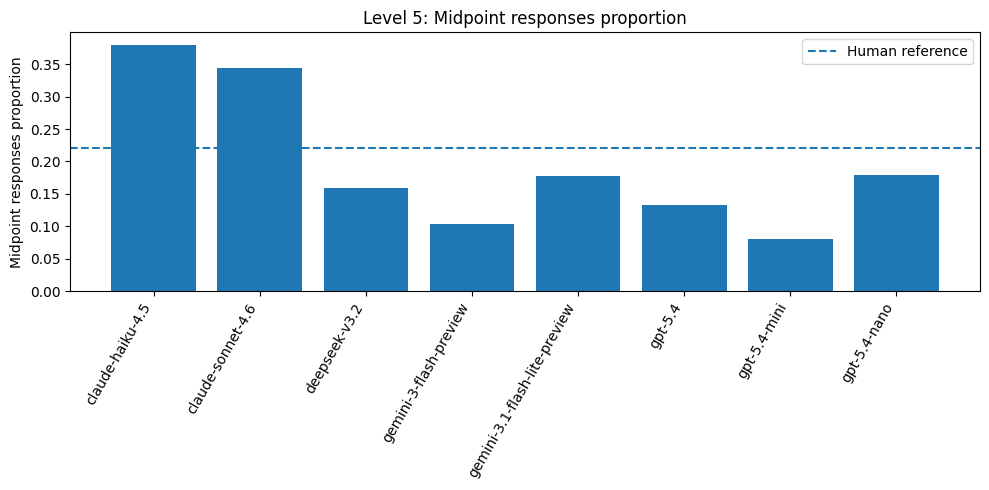

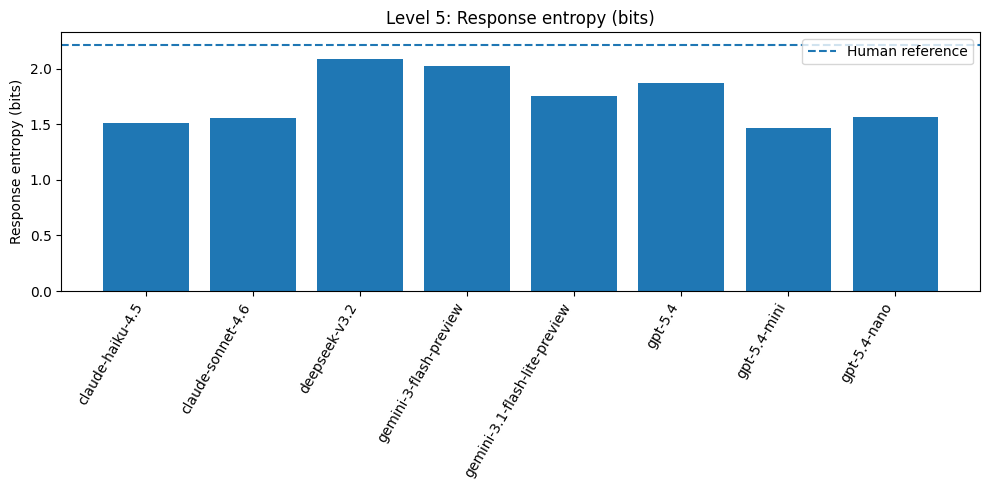

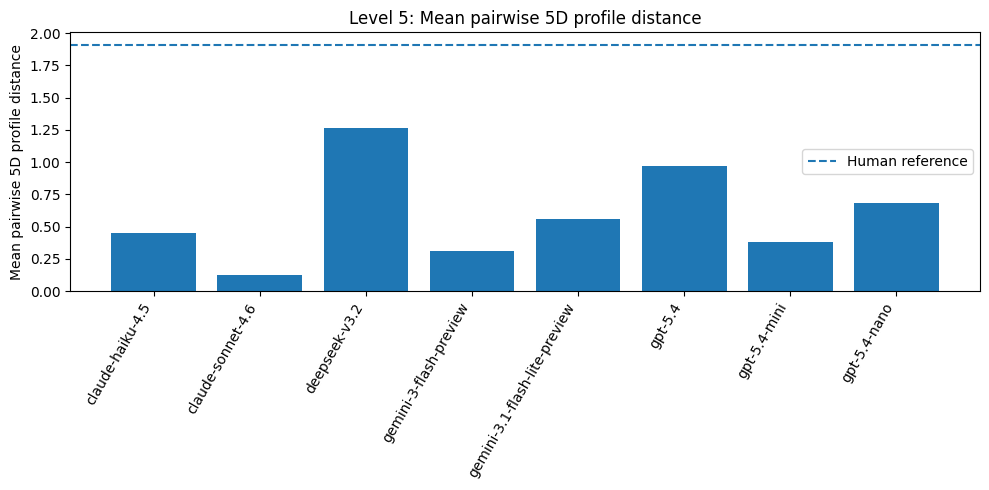

In [ ]:

# Figures: response-style metrics vs humans
metrics_to_plot = [
    ("ai_agree_prop", "human_agree_prop", "Agreeing responses proportion"),
    ("ai_extreme_prop", "human_extreme_prop", "Extreme responses proportion"),
    ("ai_midpoint_prop", "human_midpoint_prop", "Midpoint responses proportion"),
    ("ai_entropy_bits", "human_entropy_bits", "Response entropy (bits)"),
    ("ai_mean_pairwise_profile_distance", "human_mean_pairwise_profile_distance", "Mean pairwise 5D profile distance"),
]

for ai_metric, human_metric, ylabel in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(behavior_table))
    ax.bar(x, behavior_table[ai_metric])
    ax.axhline(behavior_table[human_metric].iloc[0], linestyle="--", label="Human reference")
    ax.set_xticks(x)
    ax.set_xticklabels(behavior_table["model"], rotation=60, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Level 5: {ylabel}")
    ax.legend()
    plt.tight_layout()
    save_fig(fig, f"level5_{ai_metric}")
    plt.show()



# 6) Integrated summary tables

This section creates concise summary tables by level, then a combined "at-a-glance" table you can use in the paper draft.


In [ ]:
# Summaries by level
level1_summary = central_table[[
    "model", "trait", "human_mean", "ai_mean", "mean_diff_human_minus_ai", "p_fdr", "hedges_g"
]].copy()

level2_summary = dist_table[[
    "model", "trait", "wasserstein", "wasserstein_perm_p_fdr", "energy_distance", "ks_p_fdr", "brown_forsythe_p_fdr"
]].copy()

level3_summary = rel_compare[[
    "model", "trait",
    "human_alpha", "alpha", "alpha_diff_ai_minus_human", "alpha_diff_ci_low", "alpha_diff_ci_high", "alpha_perm_p_fdr",
    "human_omega", "omega", "omega_diff_ai_minus_human", "omega_diff_ci_low", "omega_diff_ci_high", "omega_perm_p_fdr"
]].rename(columns={"alpha": "ai_alpha", "omega": "ai_omega"}).copy()

level4_summary = struct_table[[
    "model",
    "trait_corr_frobenius", "trait_corr_frobenius_perm_p_fdr",
    "trait_corr_matrix_r", "trait_corr_matrix_r_ci_low", "trait_corr_matrix_r_ci_high",
    "item_corr_frobenius", "item_corr_frobenius_perm_p_fdr",
    "item_corr_matrix_r", "item_corr_matrix_r_ci_low", "item_corr_matrix_r_ci_high",
    "human_variance_explained_5f", "model_variance_explained_5f",
    "mean_abs_tucker_congruence", "mean_abs_tucker_ci_low", "mean_abs_tucker_ci_high", "mean_abs_tucker_perm_p_fdr",
    "max_abs_tucker_congruence"
]].copy()

level5_summary = behavior_table[[
    "model", "cramers_v", "chi2_p_fdr", "ai_agree_prop", "ai_extreme_prop", "ai_midpoint_prop", "ai_entropy_bits", "ai_mean_pairwise_profile_distance"
]].copy()

save_df(level1_summary, "summary_level1")
save_df(level2_summary, "summary_level2")
save_df(level3_summary, "summary_level3")
save_df(level4_summary, "summary_level4")
save_df(level5_summary, "summary_level5")

display(level1_summary.head(10))
display(level2_summary.head(10))
display(level3_summary.head(10))
display(level4_summary.head(10))
display(level5_summary.head(10))

,model,trait,human_mean,ai_mean,mean_diff_human_minus_ai,p_fdr,hedges_g
0,claude-haiku-4.5,Agreeableness,3.756548,4.04422,-0.287672,0.0,-0.416963
1,claude-sonnet-4.6,Agreeableness,3.756548,4.07427,-0.317722,0.0,-0.460690
2,deepseek-v3.2,Agreeableness,3.756548,4.64003,-0.883482,0.0,-1.274639
3,gemini-3-flash-preview,Agreeableness,3.756548,4.40799,-0.651442,0.0,-0.944400
4,gemini-3.1-flash-lite-preview,Agreeableness,3.756548,4.19018,-0.433632,0.0,-0.627163
5,gpt-5.4,Agreeableness,3.756548,4.69615,-0.939602,0.0,-1.361281
6,gpt-5.4-mini,Agreeableness,3.756548,4.15025,-0.393702,0.0,-0.569888
7,gpt-5.4-nano,Agreeableness,3.756548,4.04404,-0.287492,0.0,-0.416768
8,claude-haiku-4.5,Conscientiousness,3.407688,3.83592,-0.428232,0.0,-0.757345
9,claude-sonnet-4.6,Conscientiousness,3.407688,3.54272,-0.135032,0.0,-0.239255


,model,trait,wasserstein,wasserstein_perm_p_fdr,energy_distance,ks_p_fdr,brown_forsythe_p_fdr
0,claude-haiku-4.5,Extraversion,0.20210,0.000999,0.298556,1.306581e-293,0.0
1,claude-haiku-4.5,Emotional_Stability,0.49210,0.000999,0.520911,0.000000e+00,0.0
2,claude-haiku-4.5,Agreeableness,0.54532,0.000999,0.558896,0.000000e+00,0.0
3,claude-haiku-4.5,Conscientiousness,0.54888,0.000999,0.645184,0.000000e+00,0.0
4,claude-haiku-4.5,Openness,0.44316,0.000999,0.487195,0.000000e+00,0.0
5,claude-sonnet-4.6,Extraversion,0.31390,0.000999,0.539539,0.000000e+00,0.0
6,claude-sonnet-4.6,Emotional_Stability,0.81998,0.000999,0.818823,0.000000e+00,0.0
7,claude-sonnet-4.6,Agreeableness,0.55056,0.000999,0.572695,0.000000e+00,0.0
8,claude-sonnet-4.6,Conscientiousness,0.42802,0.000999,0.489826,0.000000e+00,0.0
9,claude-sonnet-4.6,Openness,0.46920,0.000999,0.522915,0.000000e+00,0.0


,model,trait,human_alpha,ai_alpha,alpha_diff_ai_minus_human,alpha_diff_ci_low,alpha_diff_ci_high,alpha_perm_p_fdr,human_omega,ai_omega,omega_diff_ai_minus_human,omega_diff_ci_low,omega_diff_ci_high,omega_perm_p_fdr
0,claude-haiku-4.5,Agreeableness,0.850051,0.680418,-0.169633,NaN,NaN,NaN,0.858076,0.925052,0.066975,NaN,NaN,NaN
1,claude-sonnet-4.6,Agreeableness,0.850051,0.067990,-0.782061,NaN,NaN,NaN,0.858076,0.647070,-0.211006,NaN,NaN,NaN
2,deepseek-v3.2,Agreeableness,0.850051,0.825225,-0.024826,NaN,NaN,NaN,0.858076,0.832767,-0.025310,NaN,NaN,NaN
3,gemini-3-flash-preview,Agreeableness,0.850051,0.698036,-0.152014,NaN,NaN,NaN,0.858076,0.675324,-0.182752,NaN,NaN,NaN
4,gemini-3.1-flash-lite-preview,Agreeableness,0.850051,0.879537,0.029486,NaN,NaN,NaN,0.858076,0.894135,0.036058,NaN,NaN,NaN
5,gpt-5.4,Agreeableness,0.850051,0.554789,-0.295262,NaN,NaN,NaN,0.858076,0.556548,-0.301528,NaN,NaN,NaN
6,gpt-5.4-mini,Agreeableness,0.850051,0.836031,-0.014020,NaN,NaN,NaN,0.858076,0.943408,0.085332,NaN,NaN,NaN
7,gpt-5.4-nano,Agreeableness,0.850051,0.269533,-0.580517,NaN,NaN,NaN,0.858076,0.279561,-0.578515,NaN,NaN,NaN
8,claude-haiku-4.5,Conscientiousness,0.681618,0.744319,0.062700,NaN,NaN,NaN,0.747811,0.872754,0.124943,NaN,NaN,NaN
9,claude-sonnet-4.6,Conscientiousness,0.681618,0.457886,-0.223732,NaN,NaN,NaN,0.747811,NaN,NaN,NaN,NaN,NaN


,model,trait_corr_frobenius,trait_corr_frobenius_perm_p_fdr,trait_corr_matrix_r,trait_corr_matrix_r_ci_low,trait_corr_matrix_r_ci_high,item_corr_frobenius,item_corr_frobenius_perm_p_fdr,item_corr_matrix_r,item_corr_matrix_r_ci_low,item_corr_matrix_r_ci_high,human_variance_explained_5f,model_variance_explained_5f,mean_abs_tucker_congruence,mean_abs_tucker_ci_low,mean_abs_tucker_ci_high,mean_abs_tucker_perm_p_fdr,max_abs_tucker_congruence
0,claude-haiku-4.5,1.234804,0.004975,0.828178,0.806762,0.859369,13.131623,0.004975,0.680159,0.644751,0.672484,0.421446,0.727554,0.301531,0.289589,0.308105,1.000000,0.907825
1,claude-sonnet-4.6,1.009441,0.004975,0.065473,-0.025945,0.198402,NaN,0.004975,NaN,NaN,NaN,0.421446,0.000000,NaN,NaN,NaN,0.006633,NaN
2,deepseek-v3.2,1.231044,0.004975,0.751155,0.687919,0.755366,8.990671,0.004975,0.823837,0.808862,0.826500,0.421446,0.520843,0.412074,0.406628,0.421155,0.006633,0.945033
3,gemini-3-flash-preview,0.731452,0.004975,0.369277,0.215414,0.474268,NaN,0.004975,NaN,NaN,NaN,0.421446,0.000000,NaN,NaN,NaN,0.006633,NaN
4,gemini-3.1-flash-lite-preview,2.038228,0.004975,0.530844,0.524910,0.570471,NaN,0.004975,NaN,NaN,NaN,0.421446,0.000000,NaN,NaN,NaN,0.006633,NaN
5,gpt-5.4,1.063949,0.004975,0.714830,0.656626,0.732288,NaN,0.004975,NaN,NaN,NaN,0.421446,0.000000,NaN,NaN,NaN,0.006633,NaN
6,gpt-5.4-mini,1.835560,0.004975,0.769861,0.746251,0.789918,18.822585,0.004975,0.648781,0.634014,0.658119,0.421446,0.777854,0.337383,0.337628,0.337628,0.006633,0.937542
7,gpt-5.4-nano,0.500796,0.004975,0.664473,0.613417,0.768349,7.337320,0.004975,0.704501,0.678962,0.702286,0.421446,0.332408,0.292988,0.254052,0.279995,1.000000,0.949614


,model,cramers_v,chi2_p_fdr,ai_agree_prop,ai_extreme_prop,ai_midpoint_prop,ai_entropy_bits,ai_mean_pairwise_profile_distance
0,claude-haiku-4.5,0.182268,0.0,0.536596,0.038376,0.380384,1.509800,0.447369
1,claude-sonnet-4.6,0.171623,0.0,0.535706,0.033068,0.344276,1.558182,0.126505
2,deepseek-v3.2,0.070083,0.0,0.628738,0.347998,0.158714,2.090867,1.263569
3,gemini-3-flash-preview,0.115518,0.0,0.622574,0.375984,0.103128,2.022921,0.310224
4,gemini-3.1-flash-lite-preview,0.138687,0.0,0.630712,0.110870,0.176914,1.751728,0.559605
5,gpt-5.4,0.106429,0.0,0.673142,0.247294,0.132724,1.869770,0.972280
6,gpt-5.4-mini,0.203310,0.0,0.642904,0.048234,0.080460,1.463784,0.384189
7,gpt-5.4-nano,0.178902,0.0,0.627856,0.042450,0.179590,1.564044,0.679651



# 7) Export everything

This cell writes:
- all CSV tables
- all PNG figures
- one Excel workbook with major result tables

Then it zips the `outputs/` folder for one-click download in Colab.


In [ ]:
major_tables = {
    "level1_central": central_table,
    "level1_anova": anova_table,
    "level2_distribution": dist_table,
    "level3_reliability_compare": rel_compare,
    "level3_reliability_infer": rel_infer_table,
    "level3_item_total": itemtotal_table,
    "level3_alpha_deleted": alpha_deleted_table,
    "level4_structural": struct_table,
    "level4_structural_infer": struct_infer_table,
    "level5_behavioral": behavior_table,
}

excel_path = OUTDIR / "big5_psychometric_fidelity_results.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet, df in major_tables.items():
        df.to_excel(writer, sheet_name=sheet[:31], index=False)

import zipfile
zip_path = Path("big5_psychometric_fidelity_outputs.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in OUTDIR.rglob("*"):
        zf.write(p, p.relative_to(OUTDIR.parent))

print("Saved Excel workbook to:", excel_path)
print("Saved zip archive to:", zip_path)

Saved Excel workbook to: outputs/big5_psychometric_fidelity_results.xlsx
Saved zip archive to: big5_psychometric_fidelity_outputs.zip


In [ ]:

if IN_COLAB:
    from google.colab import files
    files.download("big5_psychometric_fidelity_outputs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 8) Notes for interpretation

## Level 1 — Central tendency fidelity
Use this to answer:
- Which models match human average scores?
- Which traits are systematically shifted up or down?

## Level 2 — Distribution fidelity
Use this to answer:
- Do models match the *shape* of human trait distributions?
- Can a model match the mean while still differing in spread, skew, or tails?

## Level 3 — Reliability fidelity
Use this to answer:
- Do model responses cohere psychometrically like human responses?
- Are some traits internally consistent for humans but not for models?

## Level 4 — Structural fidelity
Use this to answer:
- Do models preserve the same correlational and latent structure?
- Does "high Agreeableness" in a model mean the same thing psychometrically as it does in humans?

## Level 5 — Behavioral fidelity
Use this to answer:
- Do models answer like human respondents?
- Are there signs of agreement bias, compressed variability, low entropy, or unnatural profile similarity?

---

## Practical note about runtime
The most expensive step is the **Level 2 permutation testing**.

If the notebook runs slowly:
- lower `N_PERM` to 500 for quick exploration
- keep `N_PER_GROUP_FOR_DIST_TESTS` at 5000 or lower
- then rerun with stronger settings for final tables

## Practical note about reverse coding
This notebook infers reverse-coded items from the human data by default.
If you have the questionnaire's official key, edit `MANUAL_REVERSE_KEY` near the top and rerun.
